# Obesity Levels Analysis and Modeling: A Machine Learning Approach
## Angeloni Daniele
## Ingegneria Informatica e Robotica - curriculum Data Science
## Progetto Machine Learning 2023/2024


**This project is based on a dataset used to estimate the obesity levels of individuals from Mexico, Peru, and Colombia, based on their dietary habits and physical conditions. The dataset includes 17 attributes and 2111 records, with the target variable "NObeyesdad" labeling the data according to the following obesity levels: Insufficient Weight, Normal Weight, Overweight Level I, Overweight Level II, Obesity Type I, Obesity Type II, and Obesity Type III. 77% of the data was synthetically generated using the Weka tool and the SMOTE filter, while the remaining 23% was collected directly from users through a web platform. The dataset attributes include demographic variables, dietary habits, physical activity, and other behaviors relevant to assessing obesity levels.**

https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition
https://www.sciencedirect.com/science/article/pii/S2352340919306985?via%3Dihub

**Importing Libraries and Loading the Dataset**

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_curve, auc, classification_report, accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
pd.set_option('display.expand_frame_repr', False)
import warnings
warnings.filterwarnings('ignore')
import time
from IPython.display import display

data_raw = pd.read_csv("ObesityDataSet.csv")


**Dataset Exploration**

In [2]:
display(data_raw.head())
display("DataFrame Dimensions:", data_raw.shape)
display(data_raw.info())
display("Dataframe Columns:", data_raw.columns)
display(data_raw.describe())

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


'DataFrame Dimensions:'

(2111, 17)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

None

'Dataframe Columns:'

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


**Heatmap with Null Values in the Dataset**

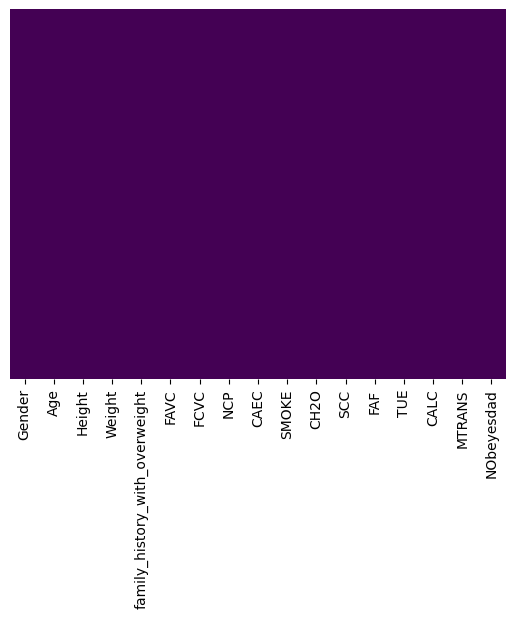

In [3]:
sns.heatmap(data_raw.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.show()

**Removing duplicate rows, keeping only one occurrence per group**
This cell is commented out because I noticed slightly worse results in the validation set.

**Displaying the unique values for the "NObeyesdad" label to understand the different classification categories. We'll also visualize the dataset's balance across these categories to ensure an even distribution.** 

In [4]:
column = 'NObeyesdad'
print(f"Unique Values for the Column '{column}':")
print(data_raw[column].value_counts())
print()

Unique Values for the Column 'NObeyesdad':
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64



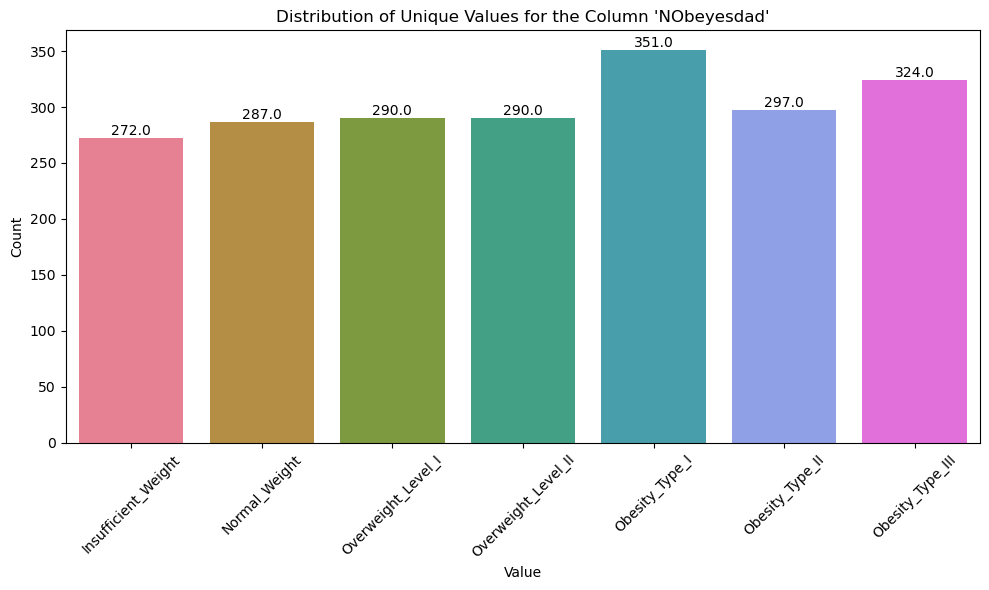

In [5]:
category_order = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]

plt.figure(figsize=(10, 6))
sns.countplot(data=data_raw, x=column, order=category_order, palette='husl')
plt.title(f"Distribution of Unique Values for the Column '{column}'")
plt.xlabel('Value')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Annotazioni per le barre
ax = plt.gca()
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

plt.tight_layout()
plt.show()

**Exploring the relationship between Age and the "NObeyesdad" label with Violin plot and Box Plot**

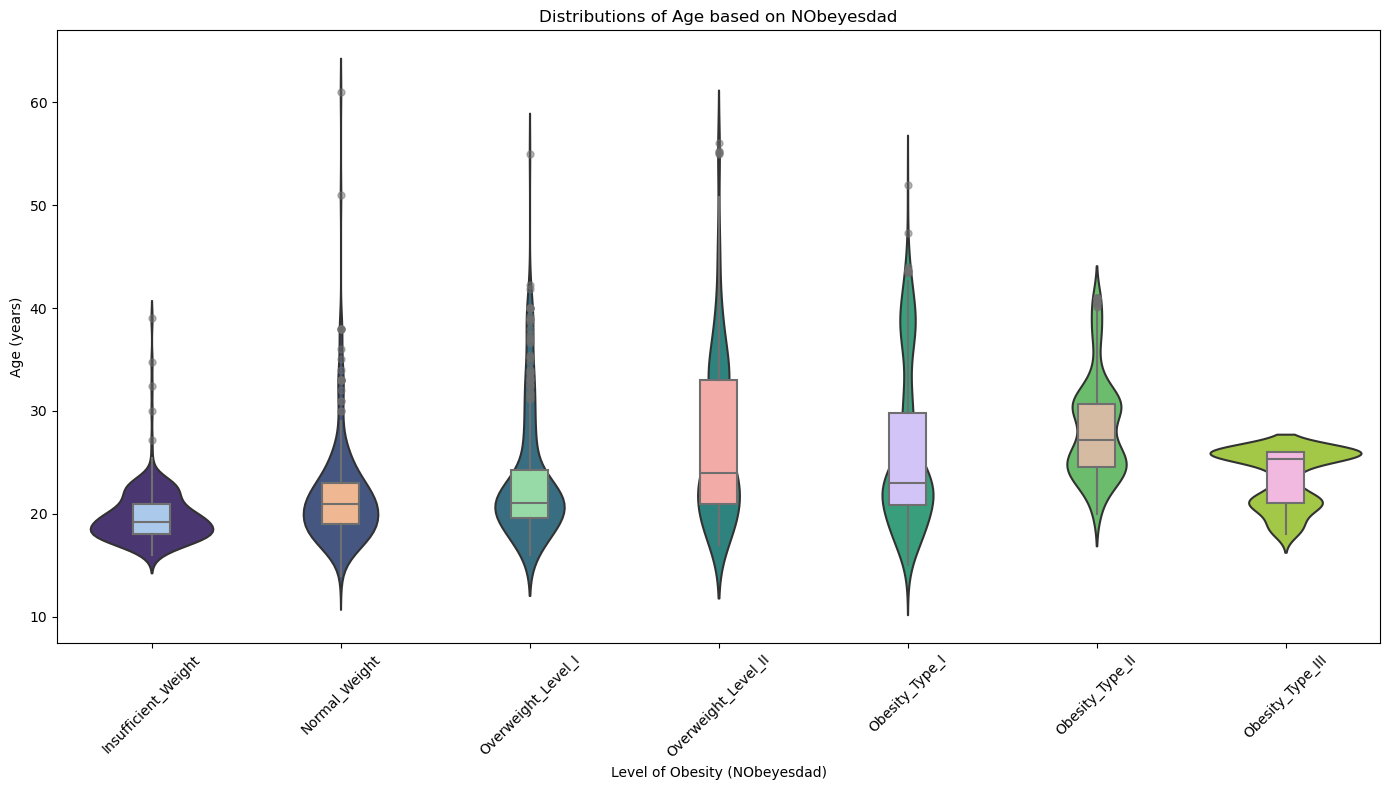

In [6]:
plt.figure(figsize=(14, 8))

sns.violinplot(x='NObeyesdad', y='Age', data=data_raw, order=category_order, palette='viridis', inner=None)

sns.boxplot(x='NObeyesdad', y='Age', data=data_raw, order=category_order, width=0.2, palette='pastel', showcaps=False, boxprops={'zorder': 2}, whiskerprops={'zorder': 2}, flierprops={'zorder': 2, 'marker': 'o', 'markersize': 5, 'linestyle': 'none', 'alpha': 0.5})

plt.title('Distributions of Age based on NObeyesdad')
plt.xlabel('Level of Obesity (NObeyesdad)')
plt.ylabel('Age (years)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Analyzing the relationship between Gender and the "NObeyesdad" label.**
Creating pie charts for each weight category to visualize the distribution.

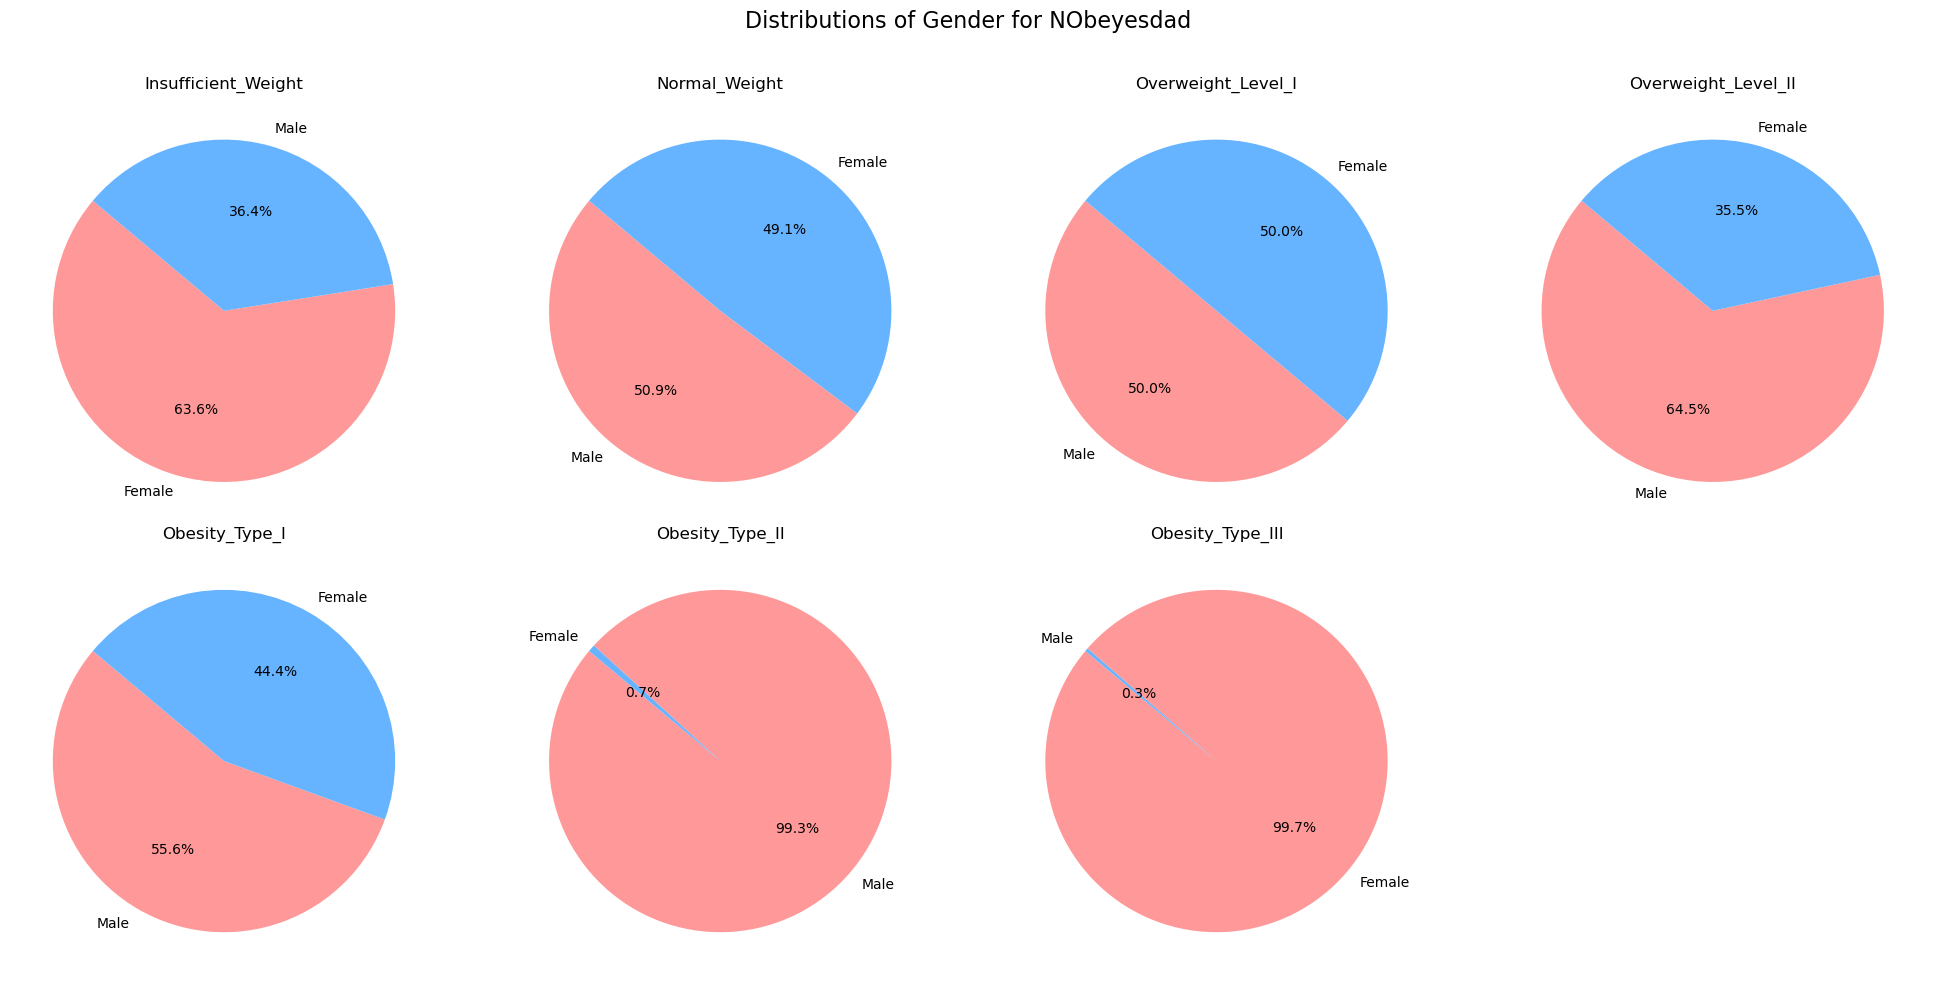

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for idx, category in enumerate(category_order):
    gender_counts = data_raw[data_raw['NObeyesdad'] == category]['Gender'].value_counts()
    axes[idx].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=140)
    axes[idx].set_title(category)
if len(category_order) < len(axes):
    fig.delaxes(axes[-1])
    
plt.suptitle('Distributions of Gender for NObeyesdad', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Creating a strip plot of Weight for each "NObeyesdad" category to visualize the weight distribution across different obesity levels.**

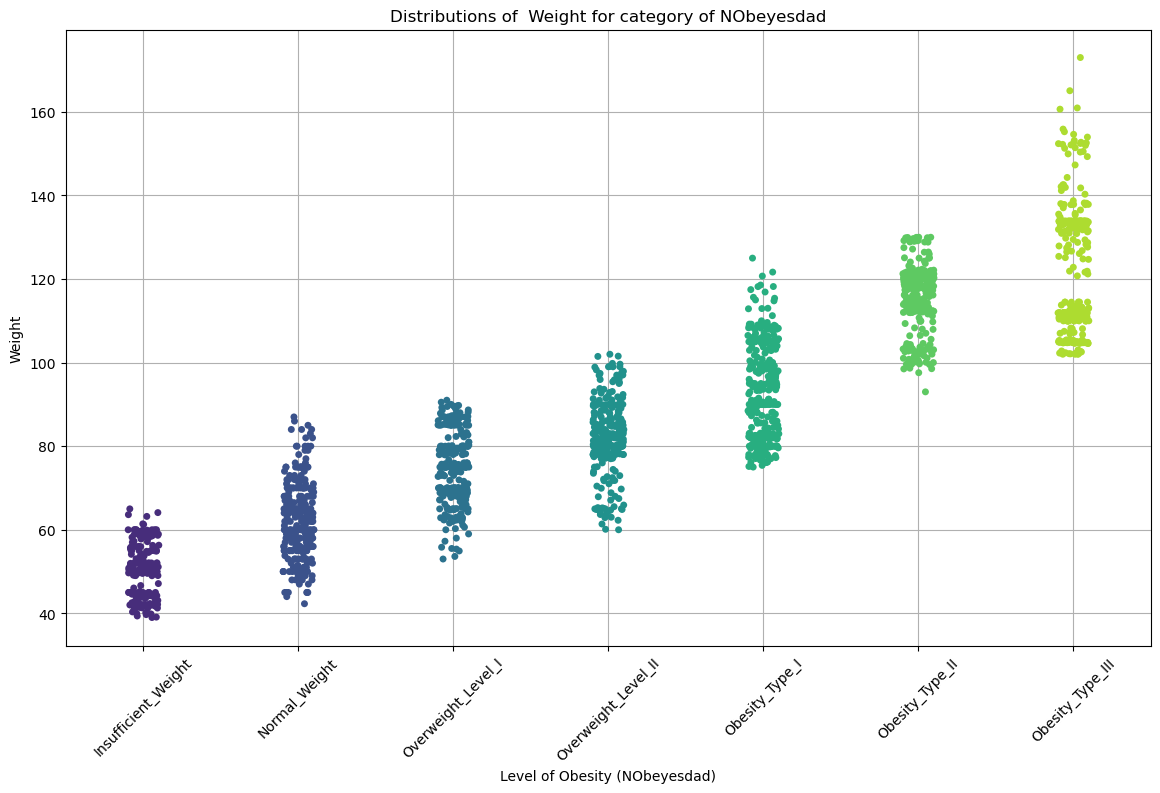

In [8]:
# Assicurati che NObeyesdad sia una categoria ordinata
data_raw['NObeyesdad'] = pd.Categorical(data_raw['NObeyesdad'], categories=category_order, ordered=True)

# Creazione del strip plot
plt.figure(figsize=(14, 8))
sns.stripplot(x='NObeyesdad', y='Weight', data=data_raw, order=category_order, palette='viridis', jitter=True)
plt.title('Distributions of  Weight for category of NObeyesdad')
plt.xlabel('Level of Obesity (NObeyesdad)')
plt.ylabel('Weight')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**Exploring the relationship between Time Using Electronic devices (TUE) and the "NObeyesdad" label to understand how technology usage correlates with different obesity levels.**

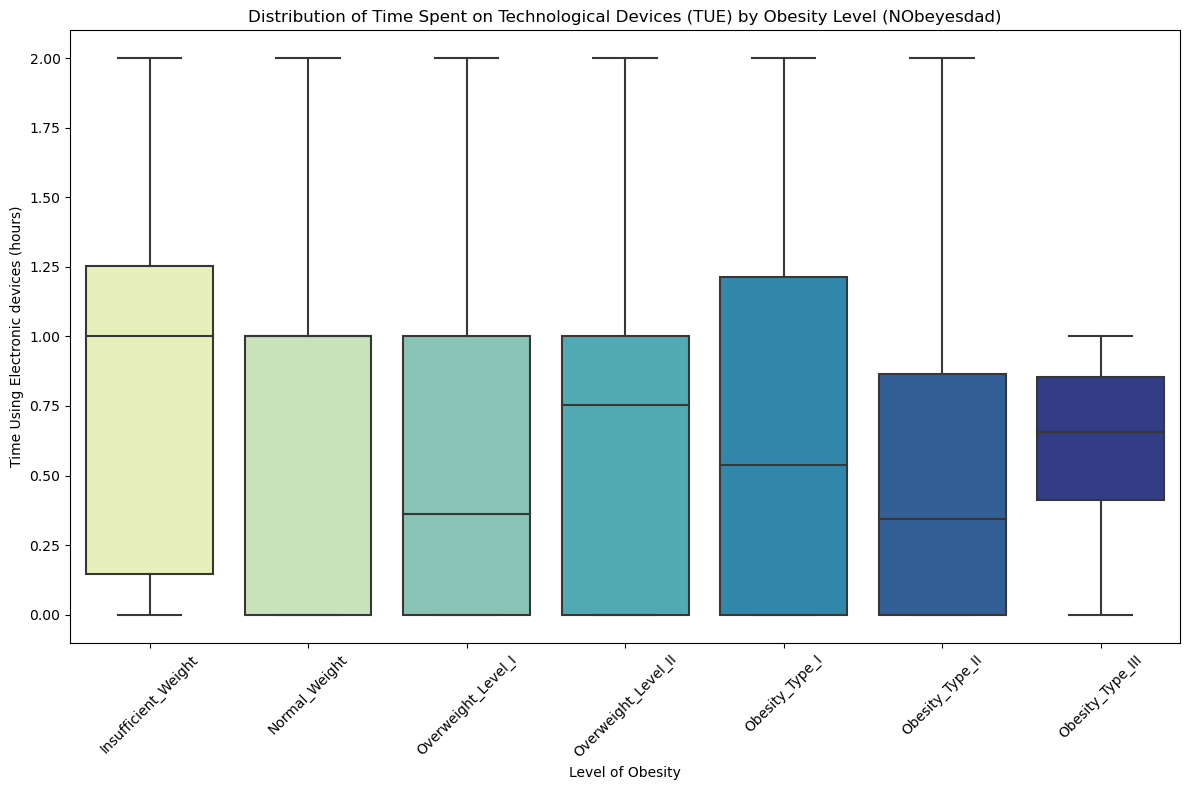

In [9]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=data_raw, x='NObeyesdad', y='TUE', palette='YlGnBu')
plt.title('Distribution of Time Spent on Technological Devices (TUE) by Obesity Level (NObeyesdad)')
plt.xlabel('Level of Obesity')
plt.ylabel('Time Using Electronic devices (hours)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Analyzing the relationship between Age, Height, Weight, and the "NObeyesdad" label using a pairplot to visualize the interactions and correlations among these variables.**

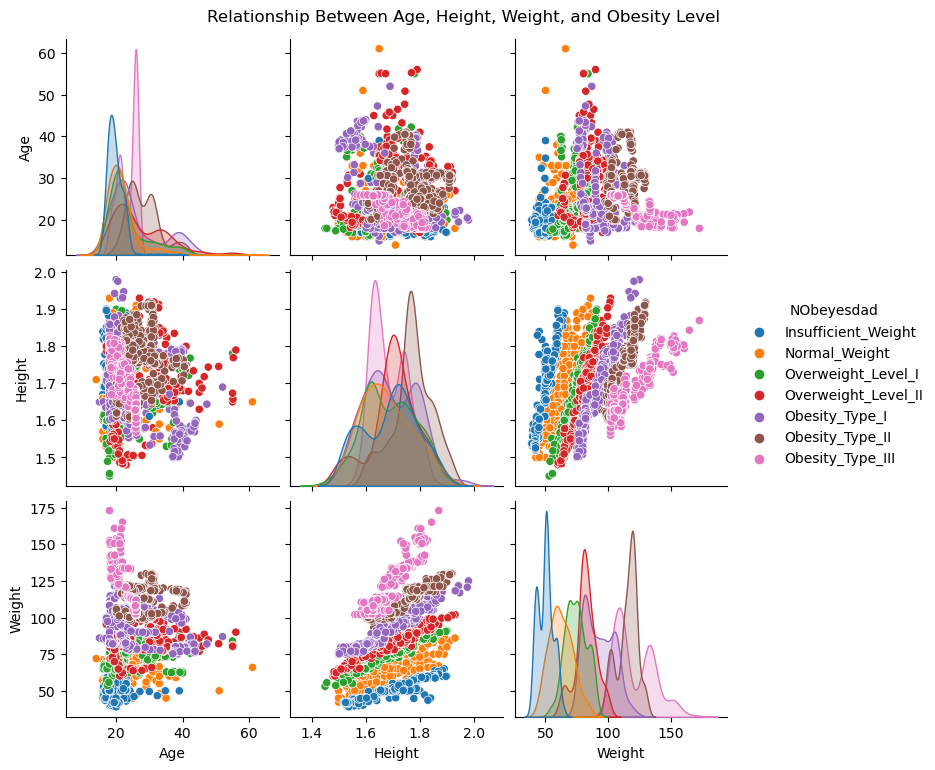

In [10]:
sns.pairplot(data=data_raw, vars=['Age', 'Height', 'Weight'], hue='NObeyesdad')
plt.suptitle('Relationship Between Age, Height, Weight, and Obesity Level', y=1.02)
plt.show()


**Showing the distribution of obesity levels based on the features Weight and Height to understand how these variables influence the classification of different obesity categories.**

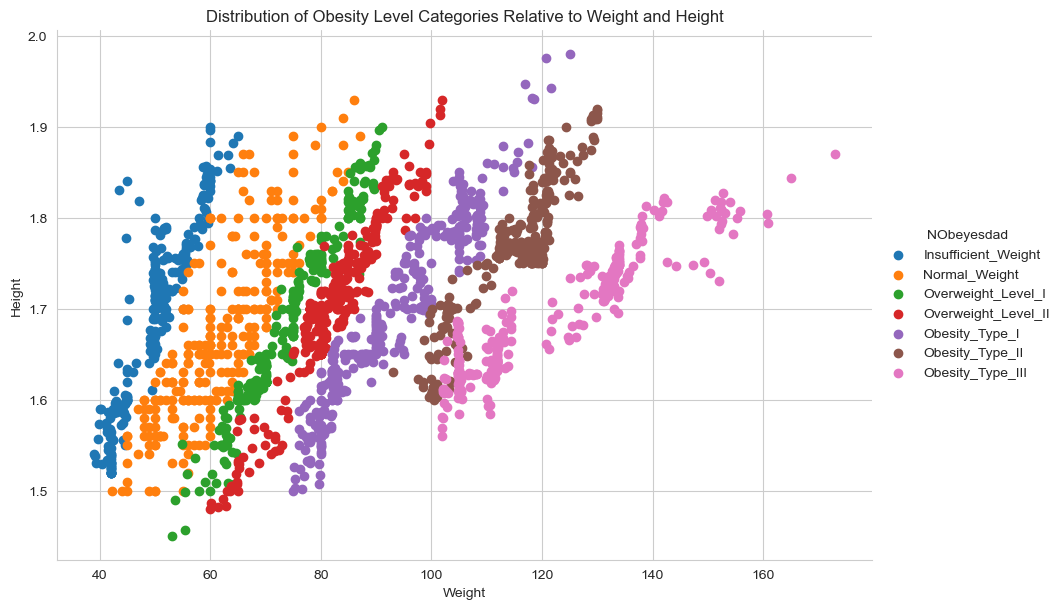

In [11]:
sns.set_style("whitegrid")
sns.FacetGrid(data_raw, hue="NObeyesdad", height=6, aspect=1.5).map(plt.scatter, "Weight", "Height").add_legend()
plt.title('Distribution of Obesity Level Categories Relative to Weight and Height')
plt.show()

**Exploring the relationship between Height and Weight using a scatter plot to visualize how these two variables correlate.**

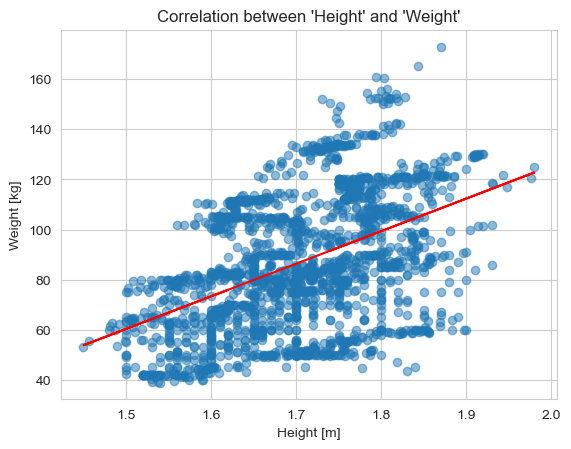

In [12]:
plt.scatter(data_raw["Height"], data_raw["Weight"], alpha=0.5)
m, b = np.polyfit(data_raw["Height"], data_raw["Weight"], 1)
plt.plot(data_raw["Height"], m * data_raw["Height"] + b, color="red")
plt.xlabel("Height [m]")
plt.ylabel("Weight [kg]")
plt.title("Correlation between 'Height' and 'Weight'")
plt.show()

**Creating a count plot to analyze the relationship between alcohol consumption (CALC) and the "NObeyesdad" label, illustrating how different levels of alcohol intake are distributed across obesity categories.**

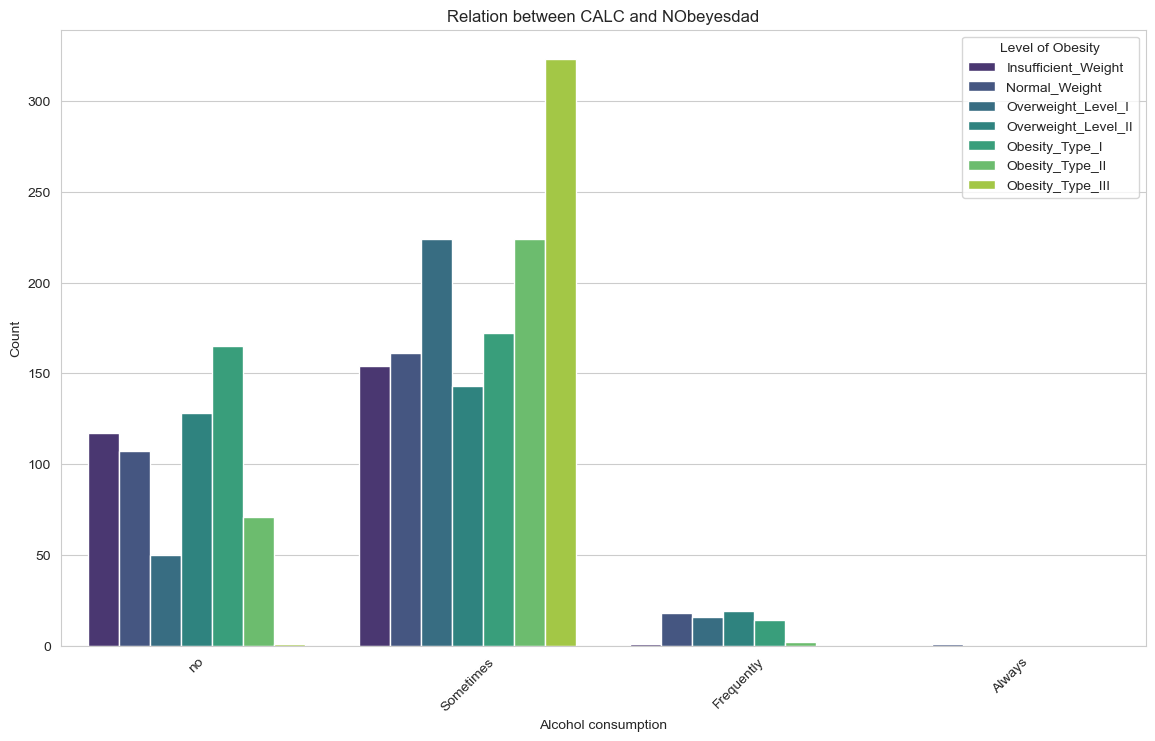

In [13]:
plt.figure(figsize=(14, 8))
sns.countplot(data=data_raw, x='CALC', hue='NObeyesdad', hue_order=category_order, palette='viridis')
plt.title('Relation between CALC and NObeyesdad')
plt.xlabel('Alcohol consumption')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Level of Obesity', loc='upper right')
plt.show()

**Creating a count plot to analyze the relationship between family history with overweight (family_history_with_overweight) and the "NObeyesdad" category, illustrating how the presence of overweight in the family correlates with different obesity levels.**

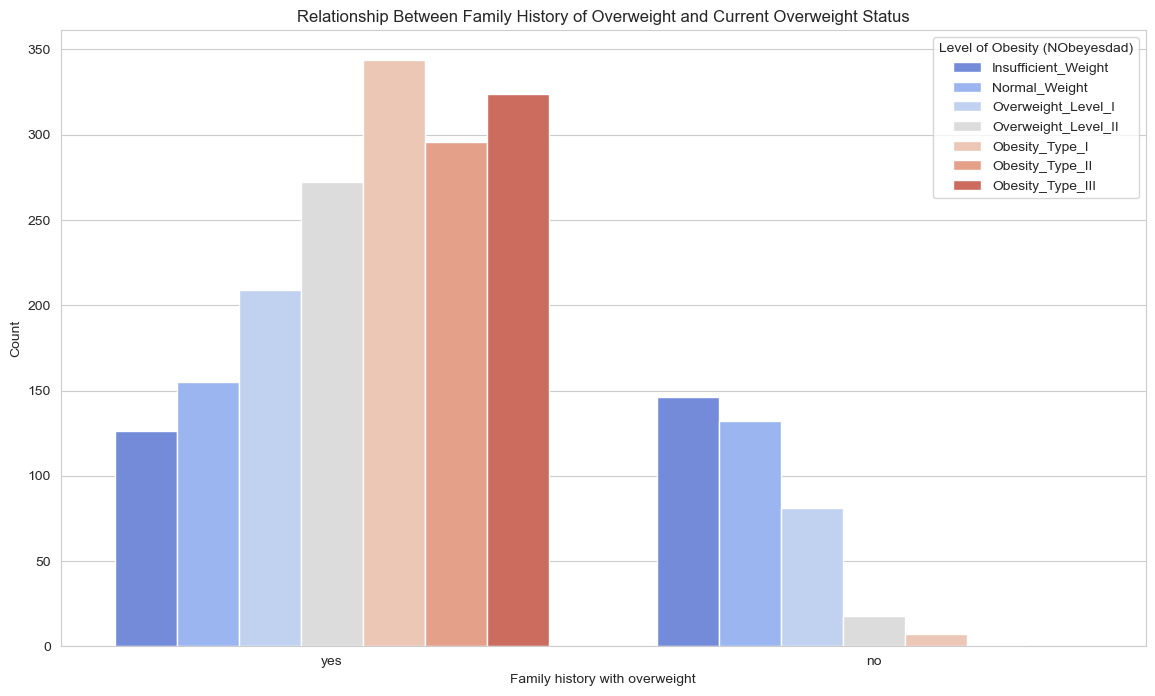

In [14]:
relation_table = pd.crosstab(data_raw['family_history_with_overweight'], data_raw['NObeyesdad'])
plt.figure(figsize=(14, 8))
sns.countplot(data=data_raw, x='family_history_with_overweight', hue='NObeyesdad', hue_order=category_order, palette='coolwarm')
plt.title('Relationship Between Family History of Overweight and Current Overweight Status')
plt.xlabel('Family history with overweight')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Level of Obesity (NObeyesdad)', loc='upper right')
plt.show()

**Exploring the relationship between the mode of transportation (MTRANS) and the "NObeyesdad" label to understand how different transportation habits correlate with obesity categories.**

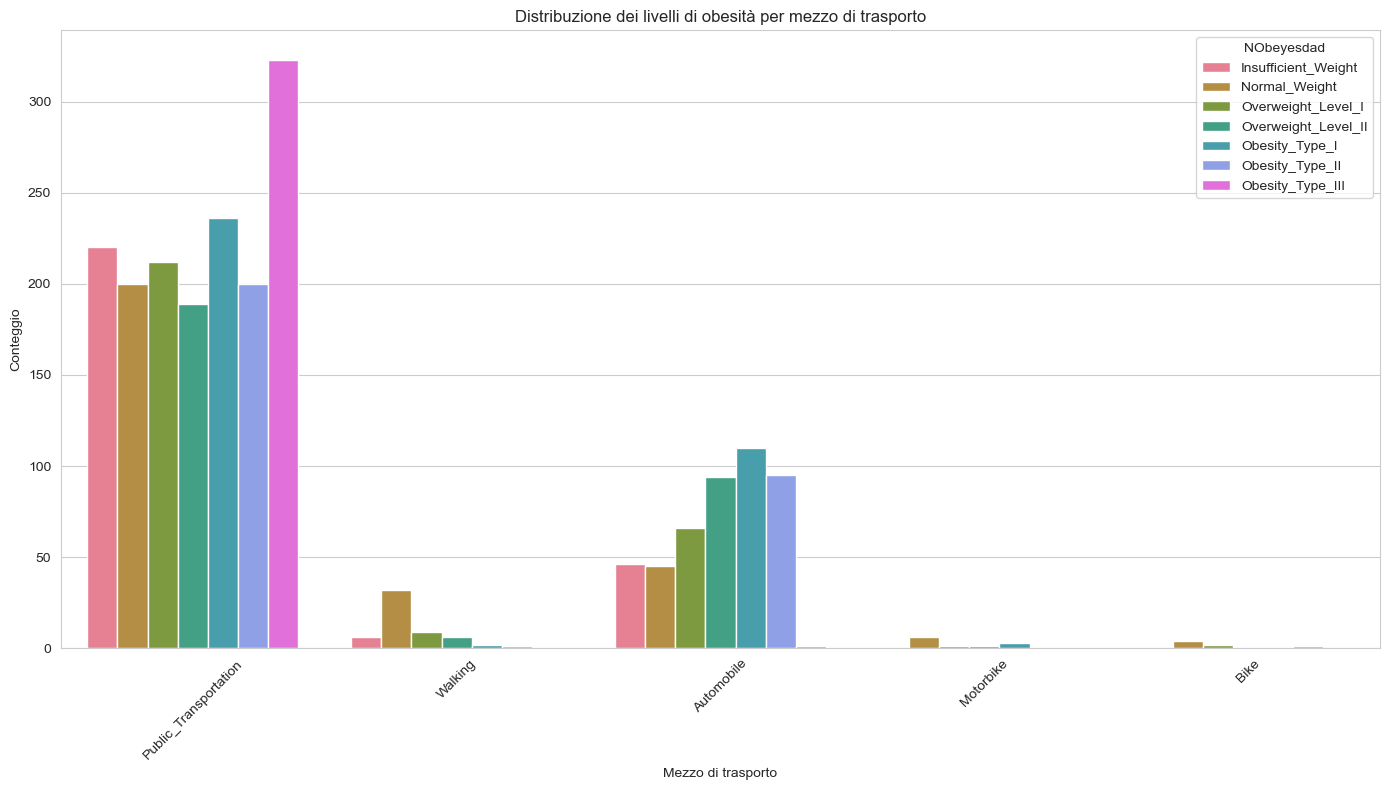

In [15]:
plt.figure(figsize=(14, 8))
sns.countplot(data=data_raw, x='MTRANS', hue='NObeyesdad', hue_order=category_order, palette='husl')
plt.title('Distribuzione dei livelli di obesità per mezzo di trasporto')
plt.xlabel('Mezzo di trasporto')
plt.ylabel('Conteggio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Analyzing with Violin Plot the relationship between the frequency of physical activity (FAF) and the "NObeyesdad" label to understand how different levels of physical activity correlate with obesity categories.**

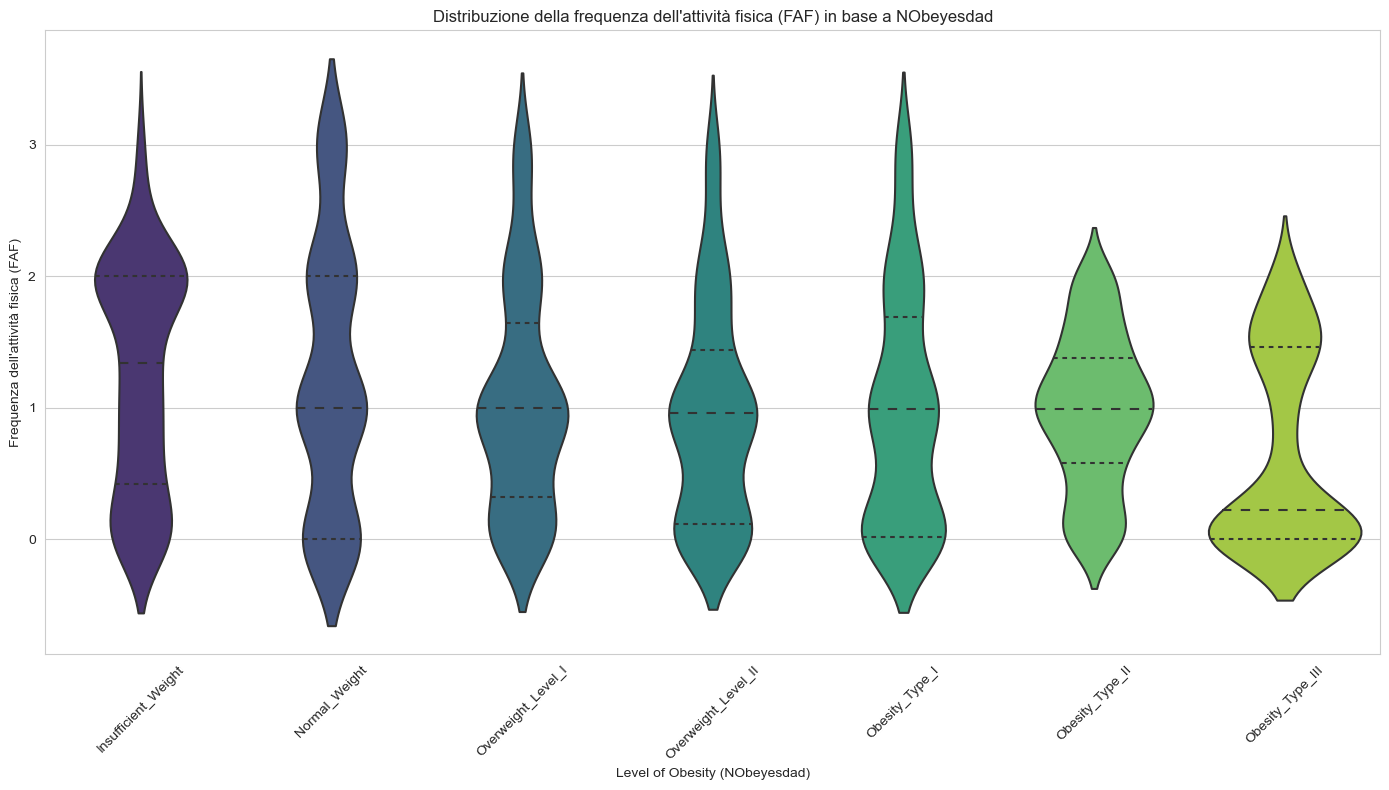

In [16]:
plt.figure(figsize=(14, 8))
sns.violinplot(x='NObeyesdad', y='FAF', data=data_raw, order=category_order, palette='viridis', inner='quartile')
plt.title('Distribuzione della frequenza dell\'attività fisica (FAF) in base a NObeyesdad')
plt.xlabel('Level of Obesity (NObeyesdad)')
plt.ylabel('Frequenza dell\'attività fisica (FAF)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Creating a violin plot to analyze the relationship between daily calorie monitoring (SCC) and the "NObeyesdad" label, visualizing how calorie monitoring correlates with different obesity categories.**

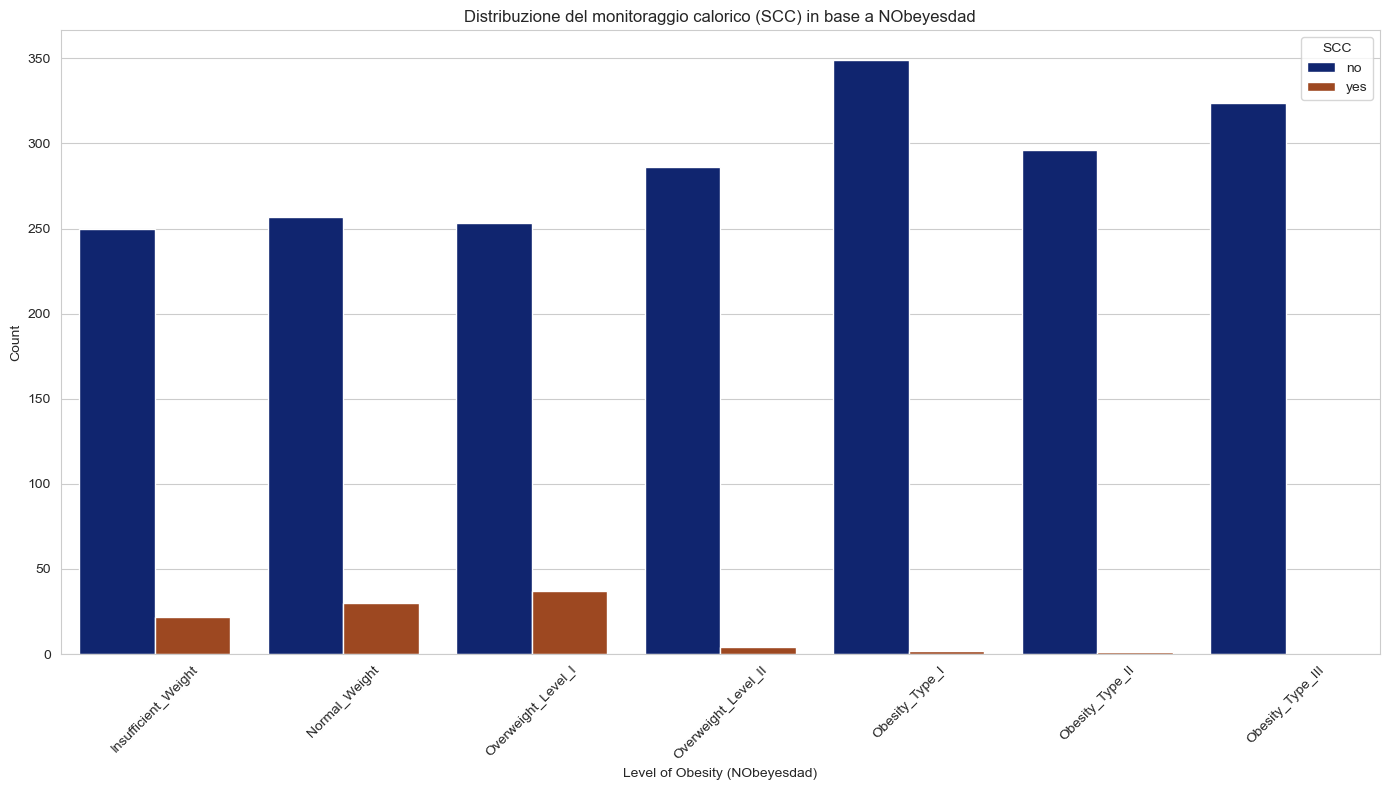

In [17]:
plt.figure(figsize=(14, 8))
sns.countplot(data=data_raw, x='NObeyesdad', hue='SCC', order=category_order, palette='dark')
plt.title('Distribuzione del monitoraggio calorico (SCC) in base a NObeyesdad')
plt.xlabel('Level of Obesity (NObeyesdad)')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Analyzing the combined relationship between the frequency of consuming high-caloric food (FAVC) and the "NObeyesdad" label to understand how high-caloric food consumption correlates with different obesity levels.**

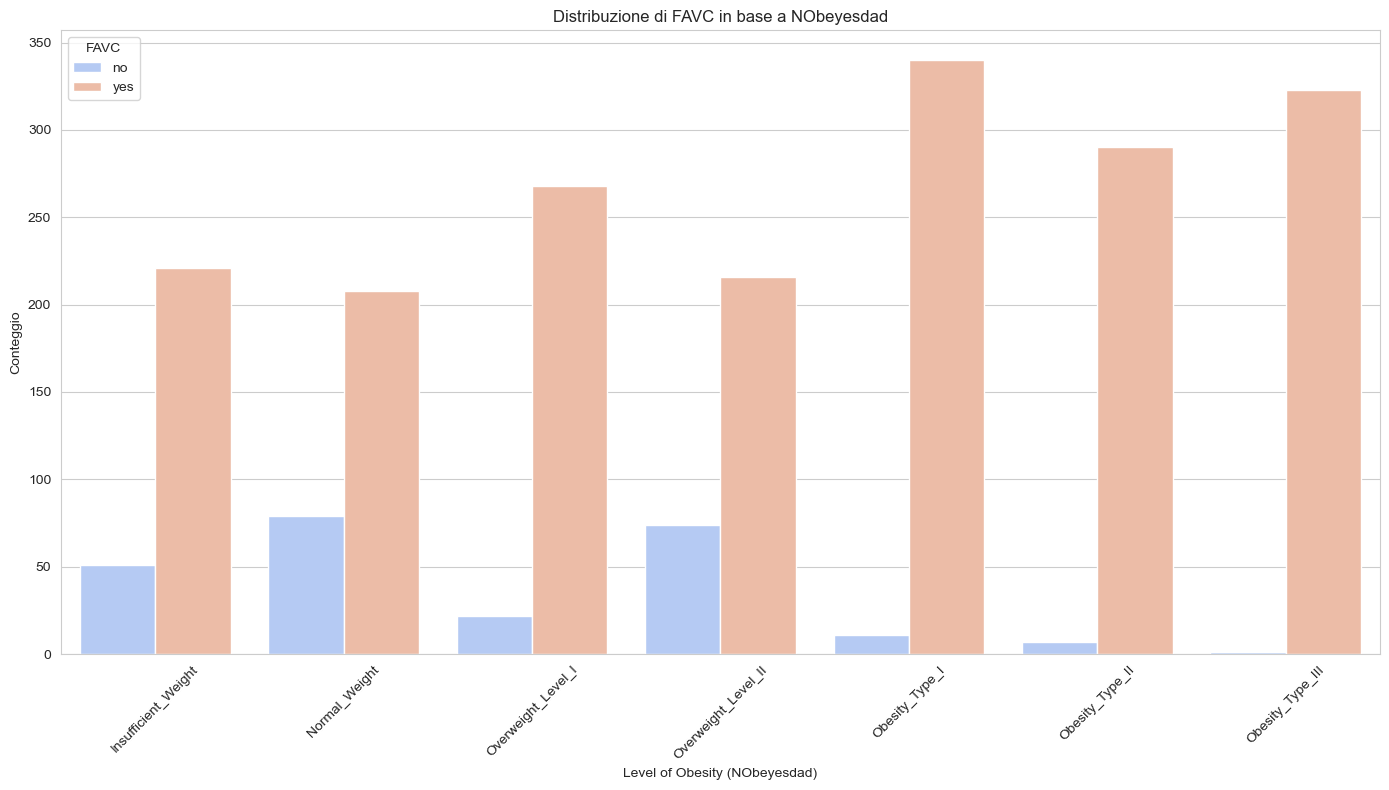

In [18]:
plt.figure(figsize=(14, 8))
sns.countplot(data=data_raw, x='NObeyesdad', hue='FAVC', order=category_order, palette='coolwarm')
plt.title('Distribuzione di FAVC in base a NObeyesdad')
plt.xlabel('Level of Obesity (NObeyesdad)')
plt.ylabel('Conteggio')
plt.legend(title='FAVC')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Exploring with Violin plot the relationship between vegetable consumption (FCVC) and the "NObeyesdad" label to understand how the frequency of eating vegetables correlates with different obesity levels.**

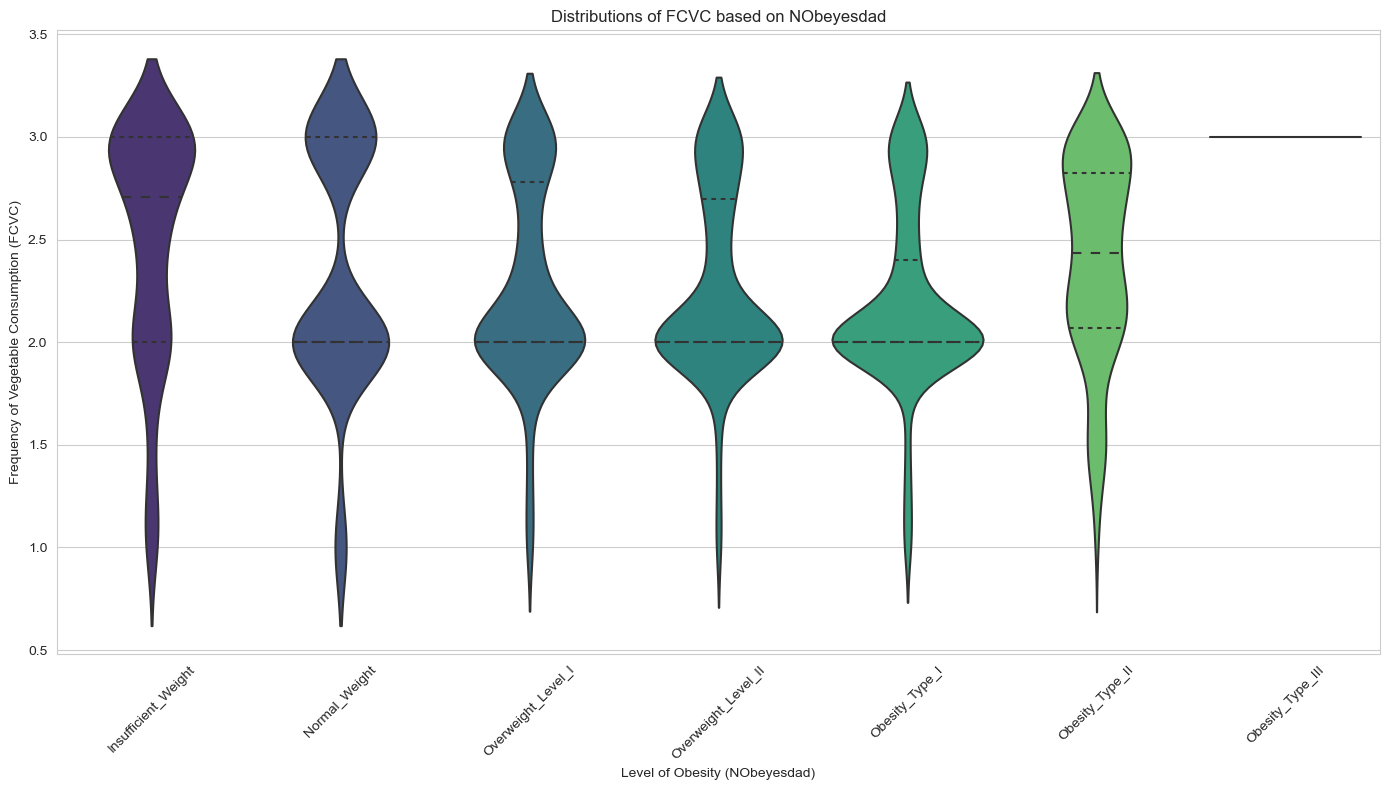

In [19]:
plt.figure(figsize=(14, 8))
sns.violinplot(x='NObeyesdad', y='FCVC', data=data_raw, order=category_order, palette='viridis', inner='quartile')
plt.title('Distributions of FCVC based on NObeyesdad')
plt.xlabel('Level of Obesity (NObeyesdad)')
plt.ylabel('Frequency of Vegetable Consumption (FCVC)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Creating a boxplot for the numerical variables to visualize their distributions and identify any potential outliers for numerical variables.**

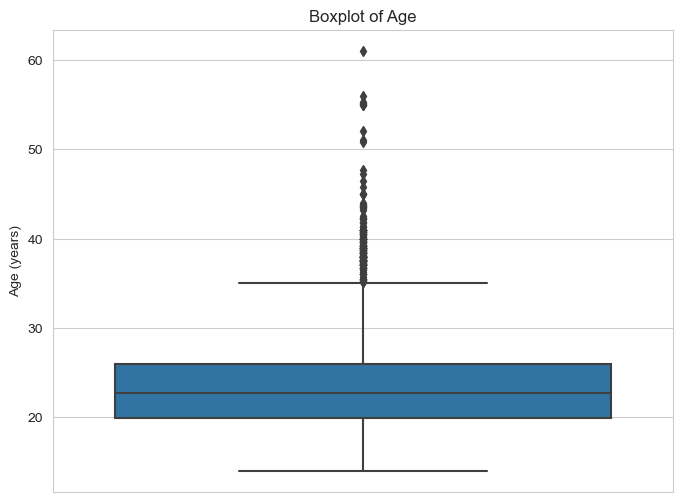

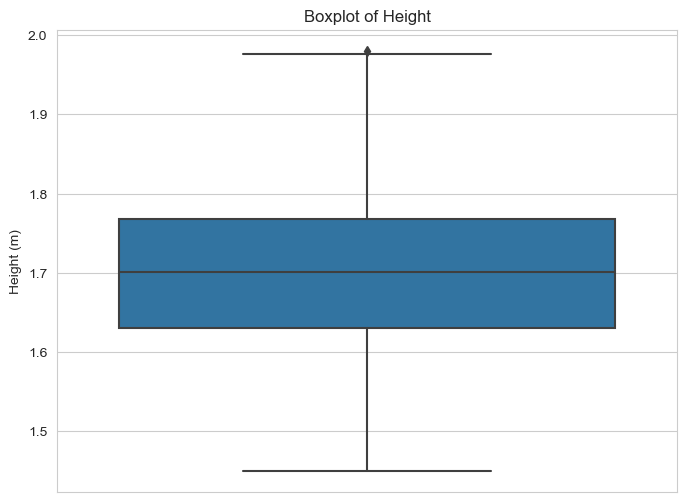

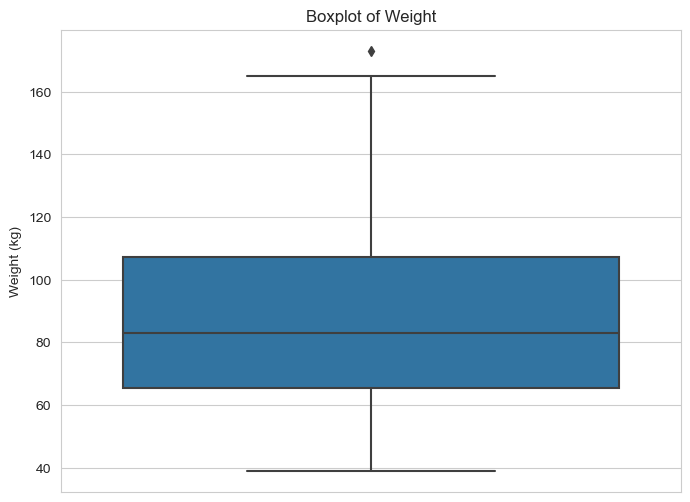

In [20]:
features_to_plot = ['Age', 'Height', 'Weight']
for feature in features_to_plot:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=data_raw[feature])
    plt.title(f'Boxplot of {feature}')
    plt.ylabel('')
    if feature == 'Height':
        plt.ylabel('Height (m)')
    elif feature == 'Weight':
        plt.ylabel('Weight (kg)')
    else:
        plt.ylabel('Age (years)')
    plt.show()

**Displaying the unique values of object-type features to determine how to handle these variables.**

Unique Values for the Column 'Gender':
Gender
Male      1068
Female    1043
Name: count, dtype: int64



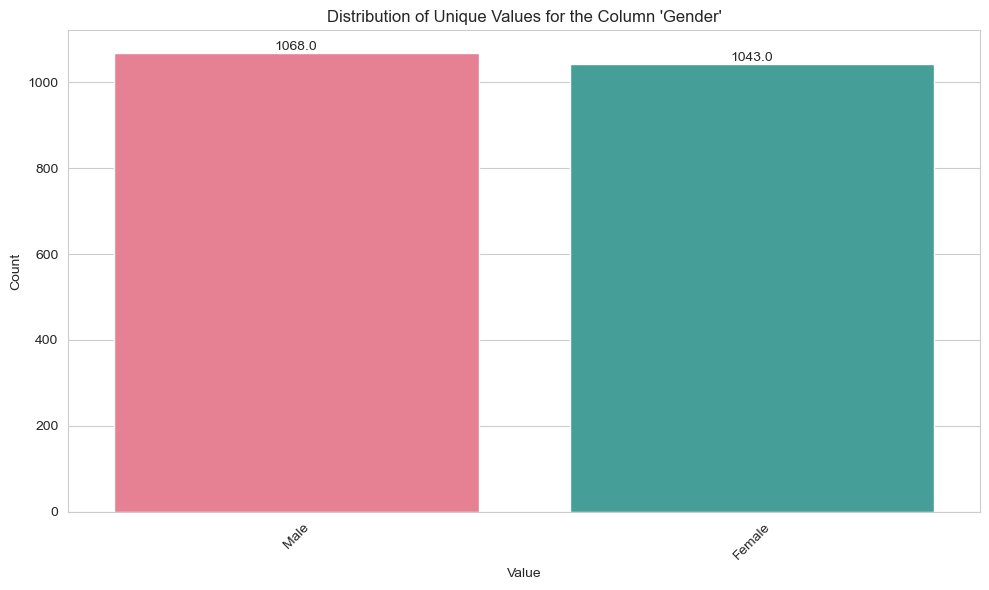

Unique Values for the Column 'family_history_with_overweight':
family_history_with_overweight
yes    1726
no      385
Name: count, dtype: int64



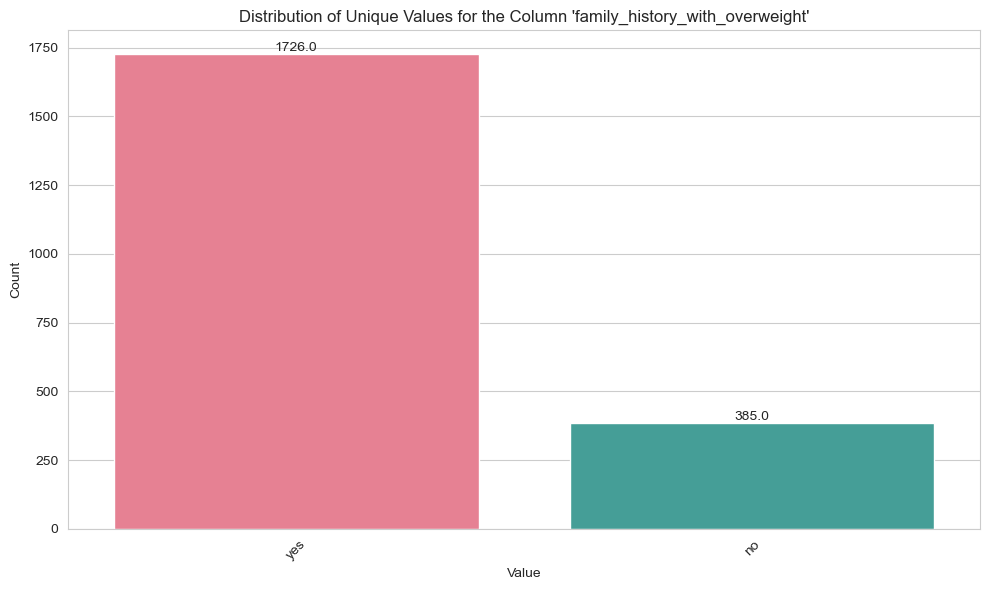

Unique Values for the Column 'FAVC':
FAVC
yes    1866
no      245
Name: count, dtype: int64



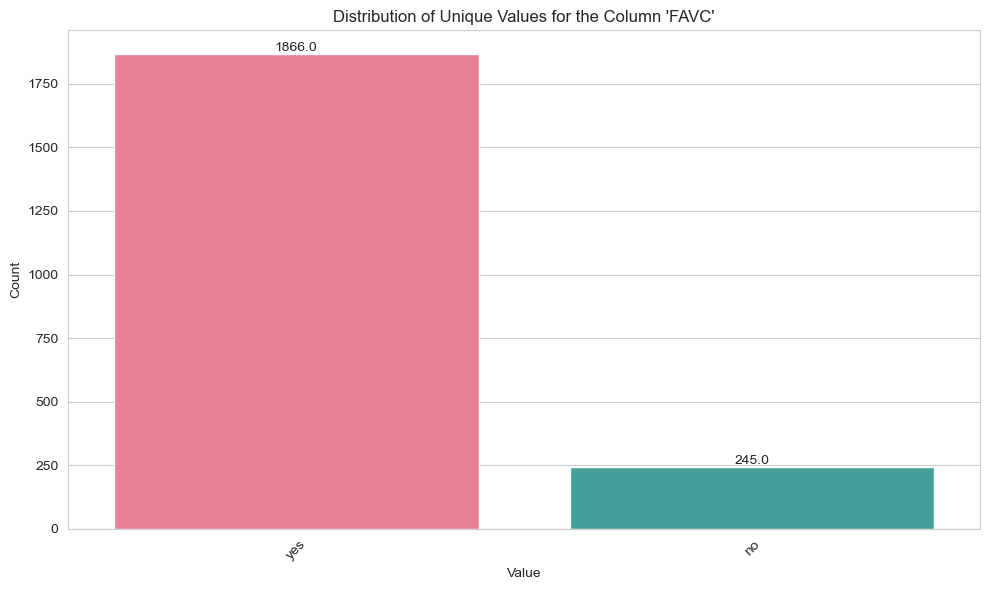

Unique Values for the Column 'CAEC':
CAEC
Sometimes     1765
Frequently     242
Always          53
no              51
Name: count, dtype: int64



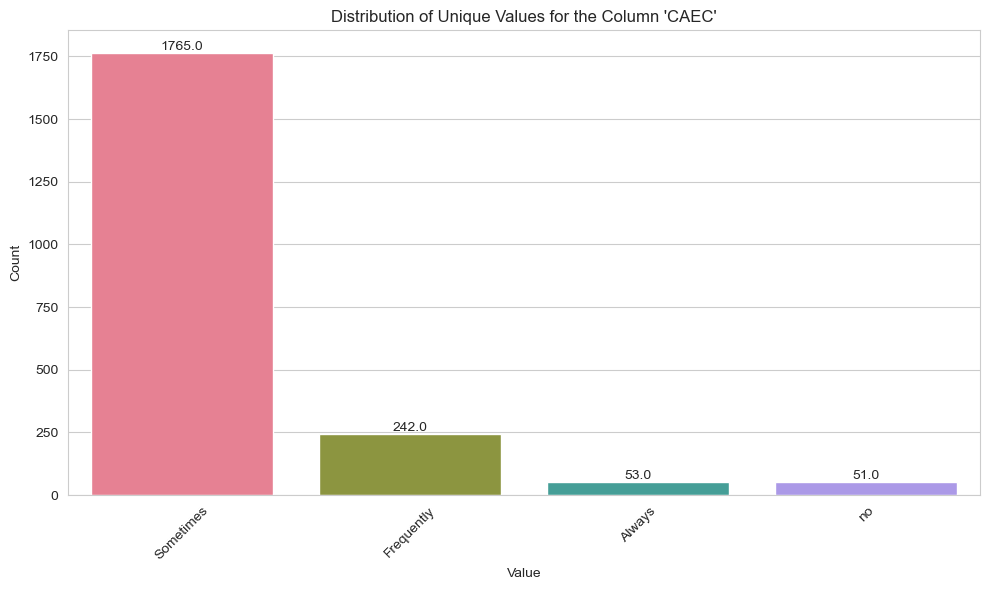

Unique Values for the Column 'SMOKE':
SMOKE
no     2067
yes      44
Name: count, dtype: int64



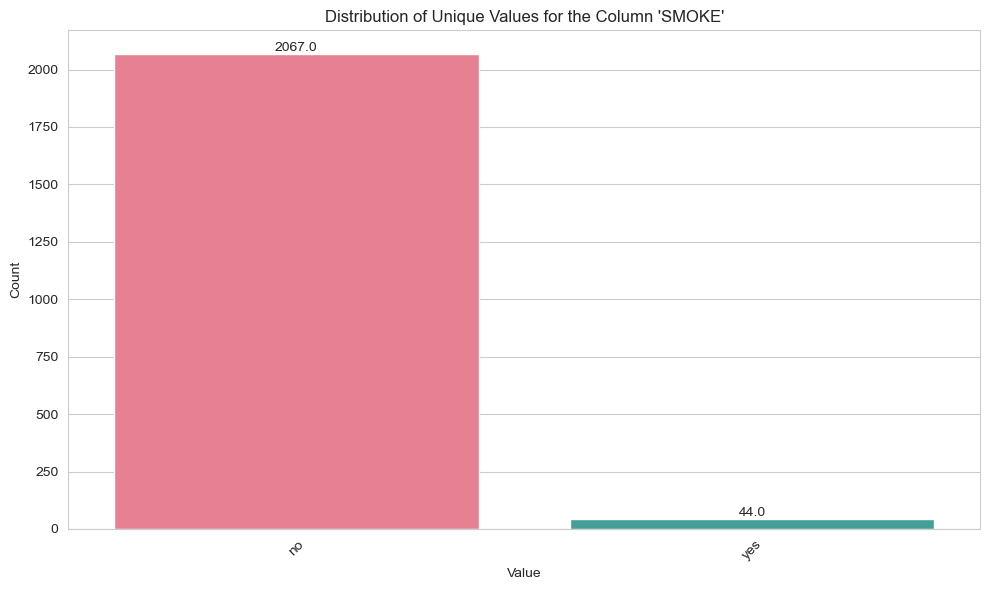

Unique Values for the Column 'SCC':
SCC
no     2015
yes      96
Name: count, dtype: int64



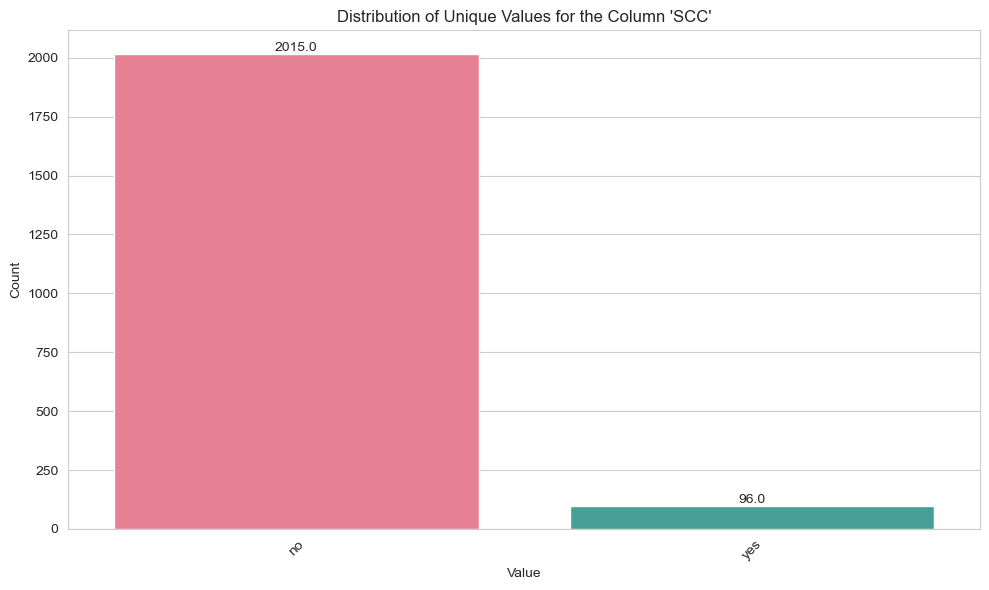

Unique Values for the Column 'CALC':
CALC
Sometimes     1401
no             639
Frequently      70
Always           1
Name: count, dtype: int64



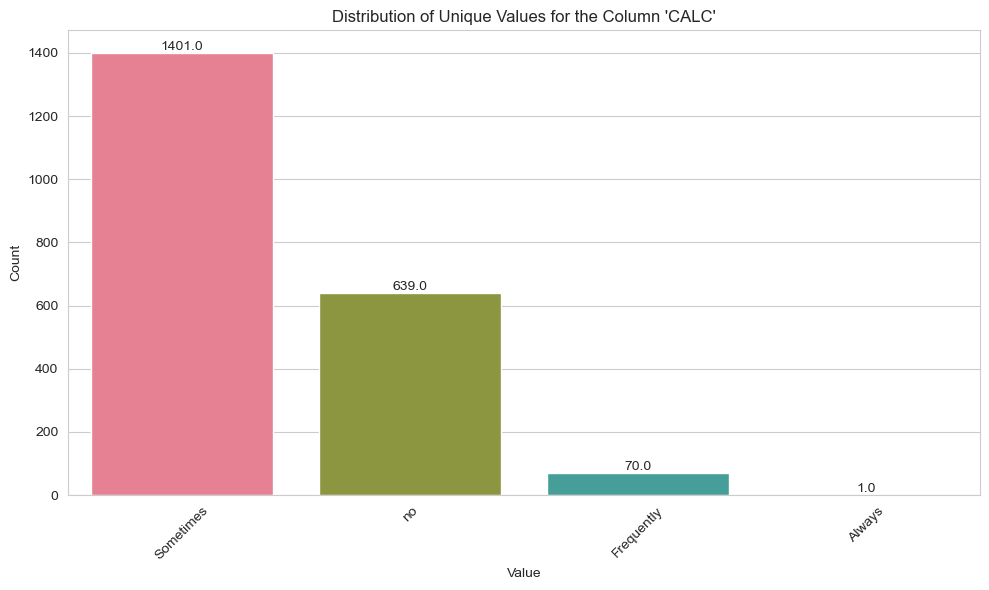

Unique Values for the Column 'MTRANS':
MTRANS
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7
Name: count, dtype: int64



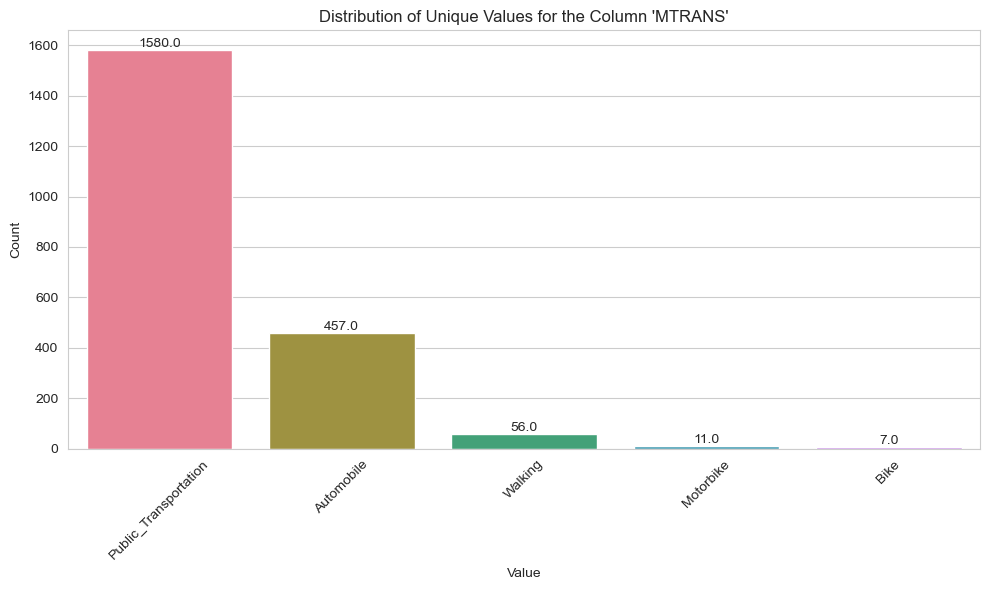

In [21]:
for column in data_raw.select_dtypes(include=['object']).columns:
    print(f"Unique Values for the Column '{column}':")
    print(data_raw[column].value_counts())
    print()

    plt.figure(figsize=(10, 6))
    sns.countplot(data=data_raw, x=column, order=data_raw[column].value_counts().index, palette='husl')
    plt.title(f"Distribution of Unique Values for the Column '{column}'")
    plt.xlabel('Value')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    
    ax = plt.gca()
    for p in ax.patches:
        ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

**Categorical variables to be transformed into numerical values through one-hot encoding (Dummizzazione).**

In [22]:
categorical_features = ['Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC', 'MTRANS']
data_encoded = pd.get_dummies(data_raw, drop_first=True, columns=categorical_features)

**Applying Label Encoding for Specific Features**
I'll use label encoding for the target label "NObeyesdad" and the features "CAEC" (food consumption between meals) and "CALC" (frequency of alcohol consumption). These features have an intrinsic logical order, making label encoding a suitable method.

In [23]:
encoding_mapping = {
    'CAEC': {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3},
    'CALC': {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3},
    'NObeyesdad': {'Insufficient_Weight': 0, 'Normal_Weight': 1, 'Overweight_Level_I': 2, 'Overweight_Level_II': 3, 'Obesity_Type_I': 4, 'Obesity_Type_II': 5, 'Obesity_Type_III': 6}
}
for column, mapping in encoding_mapping.items():
    data_encoded[column] = data_encoded[column].map(mapping)
    data_encoded[column] = data_encoded[column].astype(int)

display(data_encoded.info())
display(data_encoded)
display(data_encoded.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 2111 non-null   float64
 1   Height                              2111 non-null   float64
 2   Weight                              2111 non-null   float64
 3   FCVC                                2111 non-null   float64
 4   NCP                                 2111 non-null   float64
 5   CAEC                                2111 non-null   int32  
 6   CH2O                                2111 non-null   float64
 7   FAF                                 2111 non-null   float64
 8   TUE                                 2111 non-null   float64
 9   CALC                                2111 non-null   int32  
 10  NObeyesdad                          2111 non-null   int32  
 11  Gender_Male                         2111 no

None

,Age,Height,Weight,FCVC,NCP,CAEC,CH2O,FAF,TUE,CALC,NObeyesdad,Gender_Male,family_history_with_overweight_yes,FAVC_yes,SMOKE_yes,SCC_yes,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.000000,1.620000,64.000000,2.0,3.0,1,2.000000,0.000000,1.000000,0,1,False,True,False,False,False,False,False,True,False
1,21.000000,1.520000,56.000000,3.0,3.0,1,3.000000,3.000000,0.000000,1,1,False,True,False,True,True,False,False,True,False
2,23.000000,1.800000,77.000000,2.0,3.0,1,2.000000,2.000000,1.000000,2,1,True,True,False,False,False,False,False,True,False
3,27.000000,1.800000,87.000000,3.0,3.0,1,2.000000,2.000000,0.000000,2,2,True,False,False,False,False,False,False,False,True
4,22.000000,1.780000,89.800000,2.0,1.0,1,2.000000,0.000000,0.000000,1,3,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,20.976842,1.710730,131.408528,3.0,3.0,1,1.728139,1.676269,0.906247,1,6,False,True,True,False,False,False,False,True,False
2107,21.982942,1.748584,133.742943,3.0,3.0,1,2.005130,1.341390,0.599270,1,6,False,True,True,False,False,False,False,True,False
2108,22.524036,1.752206,133.689352,3.0,3.0,1,2.054193,1.414209,0.646288,1,6,False,True,True,False,False,False,False,True,False
2109,24.361936,1.739450,133.346641,3.0,3.0,1,2.852339,1.139107,0.586035,1,6,False,True,True,False,False,False,False,True,False


,Age,Height,Weight,FCVC,NCP,CAEC,CH2O,FAF,TUE,CALC,NObeyesdad
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,1.140692,2.008011,1.010298,0.657866,0.731407,3.112269
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.468543,0.612953,0.850592,0.608927,0.515498,1.985062
min,14.000000,1.450000,39.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.000000,1.584812,0.124505,0.000000,0.000000,1.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,1.000000,2.000000,1.000000,0.625350,1.000000,3.000000
75%,26.000000,1.768464,107.430682,3.000000,3.000000,1.000000,2.477420,1.666678,1.000000,1.000000,5.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,3.000000,2.000000,3.000000,6.000000


**Splitting Features and Label - X Design Matrix and t Target Label**
I'll divide the dataset into features (X) and the target label (t). The features (X) will form the design matrix, which includes all the independent variables used to predict the target. The target label (t) will contain the dependent variable, "NObeyesdad," which represents the obesity level.

In [24]:
X = data_encoded.drop(columns=['NObeyesdad'])
t = data_encoded['NObeyesdad'].values
feature_names = X.columns

**Correlation Matrix**
Creating a correlation matrix to examine relationships between numerical features and identify strong correlations.

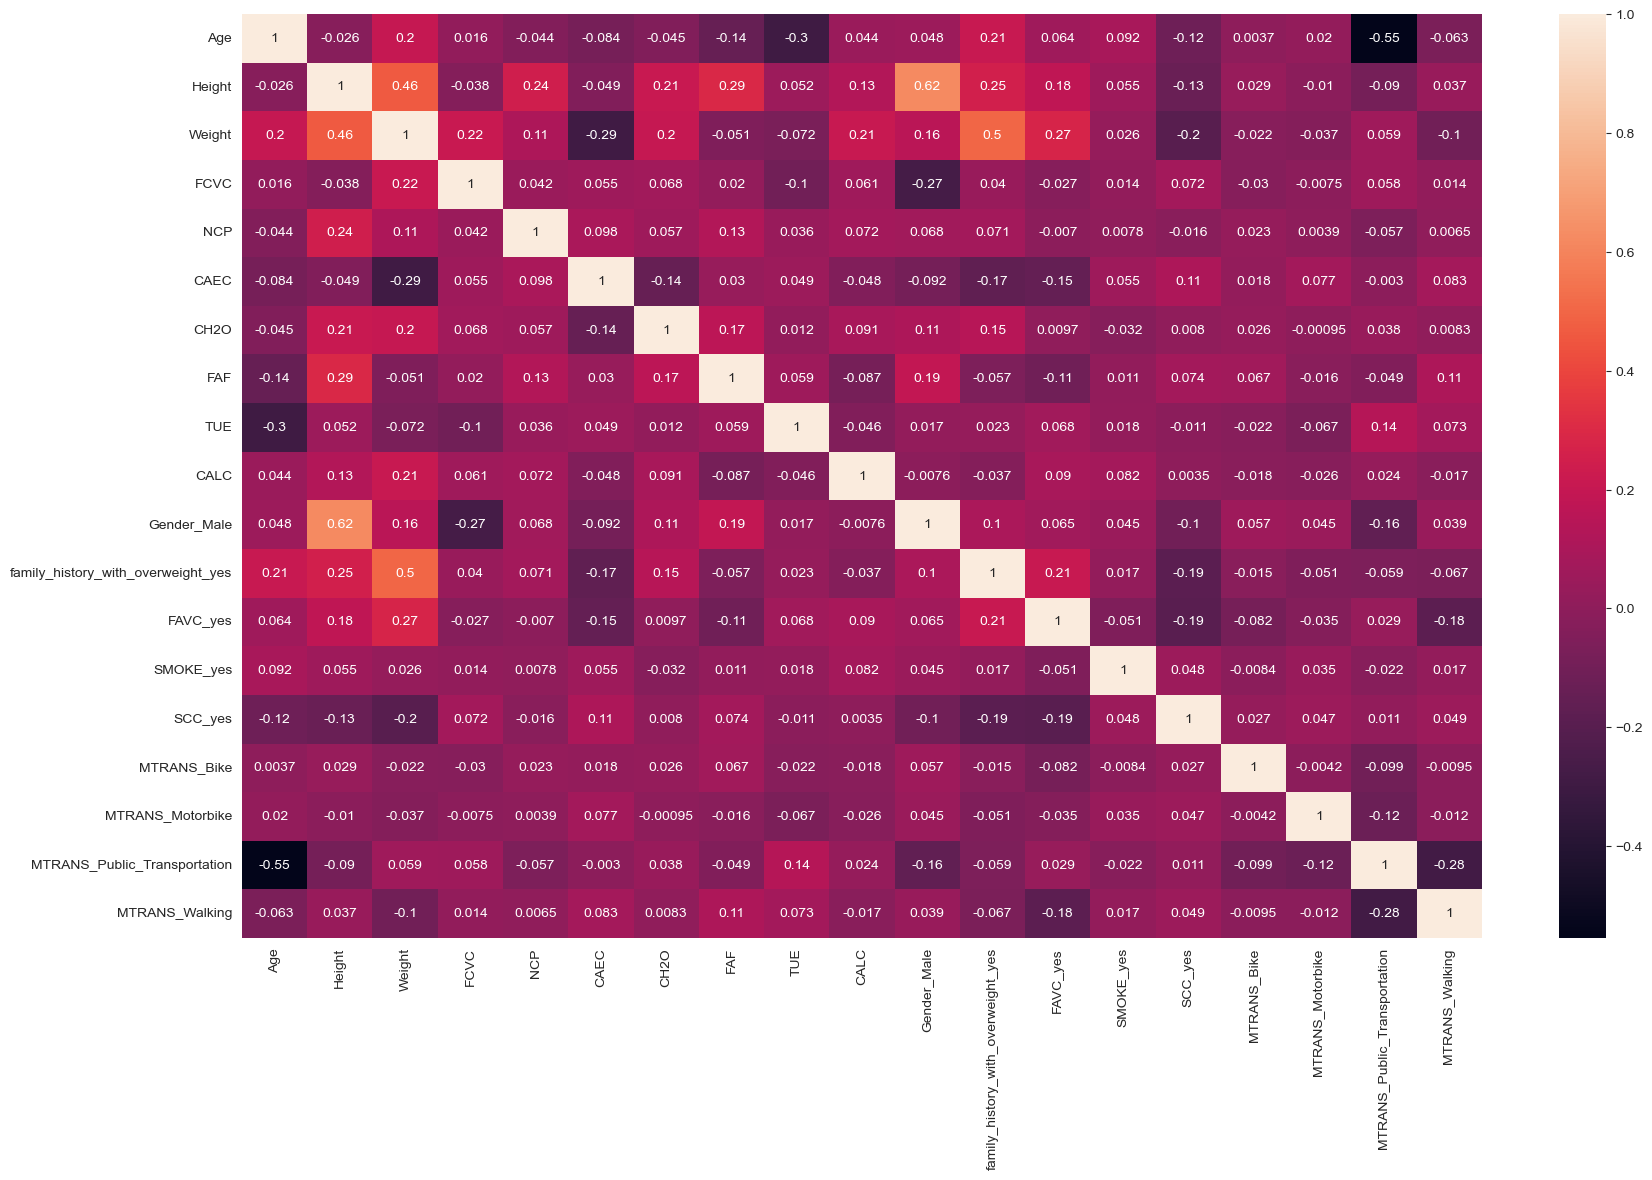

In [25]:
plt.figure(figsize=(20, 12))
corr_matrix = X.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True)
plt.show()

**Visualizing collinearity between features and the target label to identify important features for classification.**

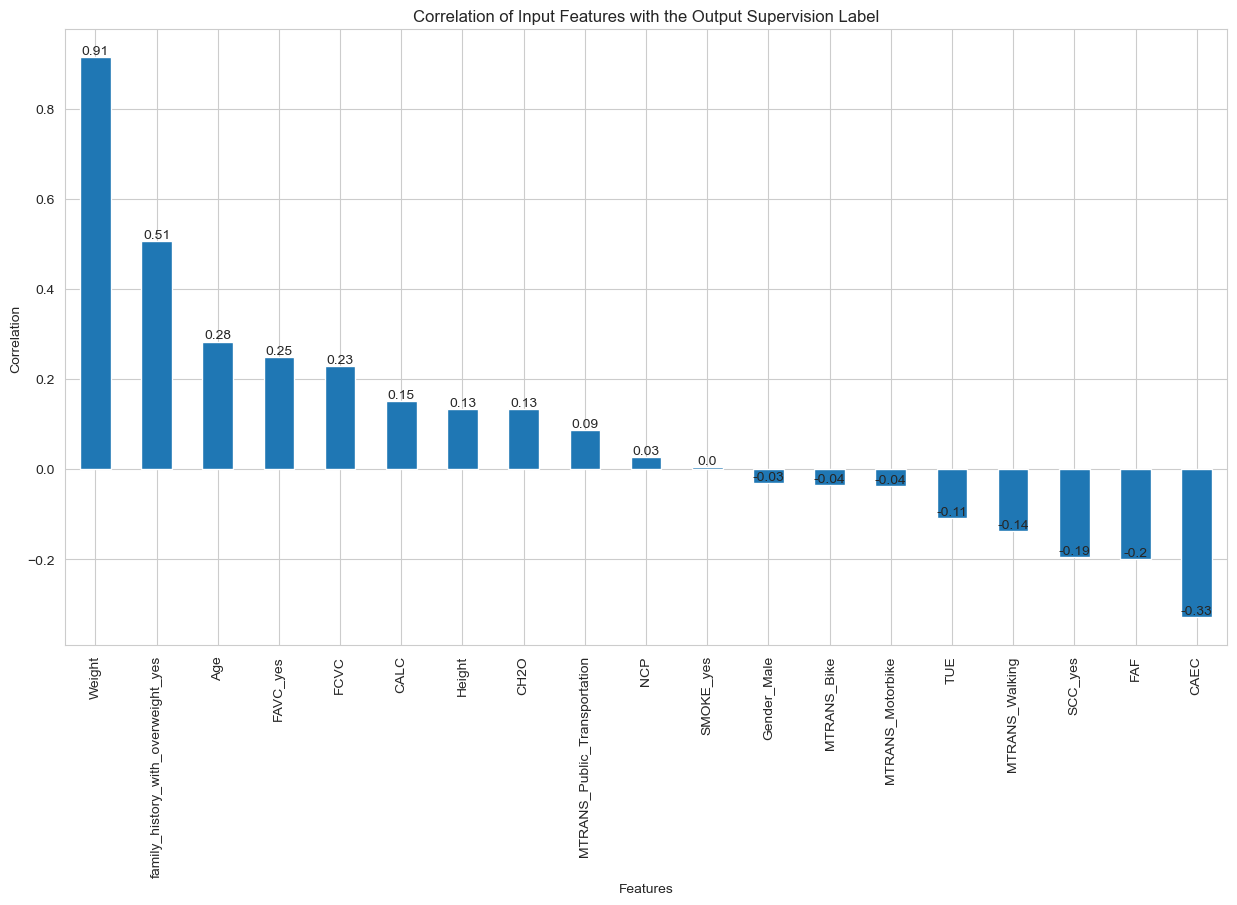

In [26]:
correlation = data_encoded.corr()['NObeyesdad'].sort_values(ascending=False)
correlation = correlation.drop('NObeyesdad')
plt.figure(figsize=(15, 8))
correlation.plot(kind='bar')
for i, value in enumerate(correlation):
    plt.text(i, value, round(value, 2), ha='center', va='bottom')
plt.title("Correlation of Input Features with the Output Supervision Label")
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.show()

**Calculating the New Feature BMI**
I'll calculate the new feature Body Mass Index (BMI) using the formula: BMI = Weight (kg) / Height (m)^2. After calculating BMI, I'll remove the original features Weight and Height from the dataset.

**Splitting the Dataset**
I'll split the dataset into three sets:
Training set (70%)
Development set (10%)
Test set (20%)

In [27]:
X_train, X_temp30, t_train, t_temp30 = train_test_split(X, t, train_size=0.7, test_size=0.3, random_state=100)
X_dev, X_test, t_dev, t_test = train_test_split(X_temp30, t_temp30, train_size=0.33, test_size=0.67, random_state=100)

**Feature Normalization**
I'll normalize the features using Standard Scaler, as it provided better results compared to MinMaxScaler.

In [28]:
stdscaler = StandardScaler()
minmaxscaler = MinMaxScaler()
X_train_scaled = stdscaler.fit_transform(X_train)
X_dev_scaled = stdscaler.transform(X_dev)
X_test_scaled = stdscaler.transform(X_test)

**Calculating VIF**
I'll calculate the Variance Inflation Factor (VIF) on normalized data, with a threshold of 5 to check for multicollinearity among the features.
https://bchuan110.medium.com/improve-your-model-by-removing-multicollinearity-83fa73119b84#:~:text=Before%20proceeding%20to%20calculate%20the,normalize%20your%20data%20at%20first.

     VIF
1   2.65
2   2.32
0   2.03
17  2.03
10  1.91
11  1.51
18  1.26
3   1.25
7   1.24
5   1.21
12  1.21
6   1.15
8   1.14
9   1.13
4   1.12
14  1.12
13  1.04
15  1.04
16  1.04


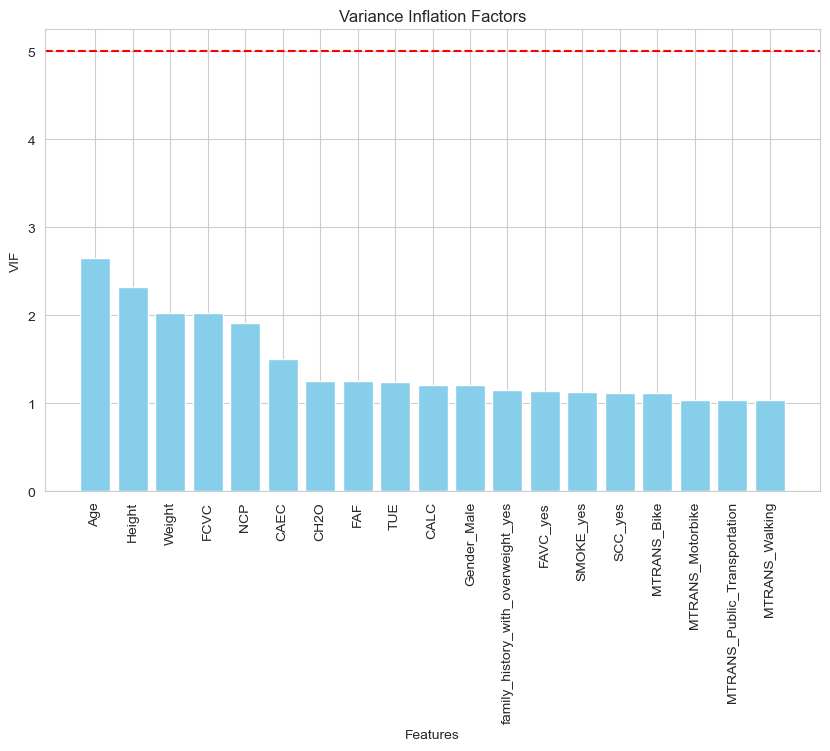

In [29]:
X_float64 = X_train_scaled.astype('float64')
vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(X_float64, i) for i in range(X_float64.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by="VIF", ascending=False)
print(vif)

# Creazione del plot per i valori VIF con soglia=5
plt.figure(figsize=(10, 6))
plt.bar(feature_names, vif['VIF'], color='skyblue')
plt.axhline(y=5, color='r', linestyle='--')
plt.xlabel('Features')
plt.ylabel('VIF')
plt.title('Variance Inflation Factors')
plt.xticks(rotation=90)
plt.show()

**Function to Plot ROC-AUC Curve and Display Metrics**
I'll define a function that plots the Receiver Operating Characteristic (ROC) curve and calculates the Area Under the Curve (AUC) score. Additionally, it will display other relevant classification metrics such as accuracy, precision, recall, and F1-score.

In [30]:
def plot_roc_auc(model, X_dev_scaled, t_dev, model_name, accuracy_dev, f1_dev):
    
    num_classes = len(np.unique(t_dev))
    probabilities_dev = model.predict_proba(X_dev_scaled)
    t_dev_bin = label_binarize(t_dev, classes=np.unique(t_dev))
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(t_dev_bin[:, i], probabilities_dev[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(10, 8))
    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], linestyle='--', color='r', label='Random')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Curva ROC-AUC on Development Set for {model_name}')
    plt.legend(loc="lower right")
    plt.grid(True)

    plt.text(0.6, 0.2, f'Accuracy: {accuracy_dev:.3f}\nF1-score: {f1_dev:.3f}', bbox=dict(facecolor='white', alpha=0.5))
    plt.show()

**Function for Confusion Matrix Visualization**

In [31]:
def plot_confusion_matrix(y_true, y_pred, labels, title='Matrice di Confusione'):

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, linewidths=.5, linecolor='black', cbar=False)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

**Using KNN, Logistic Regression, SVM, and Neural Network with Model Selection via K-Fold Cross-Validation and GridSearch for Parameter Optimization, and Testing on Development Set**

**K-Nearest Neighbors (Baseline)**

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best Parameters Found via GridSearchCV:
{'algorithm': 'auto', 'leaf_size': 10, 'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
12.596740007400513
Accuracy Training set:  1.0
F1-score Training set:  1.0


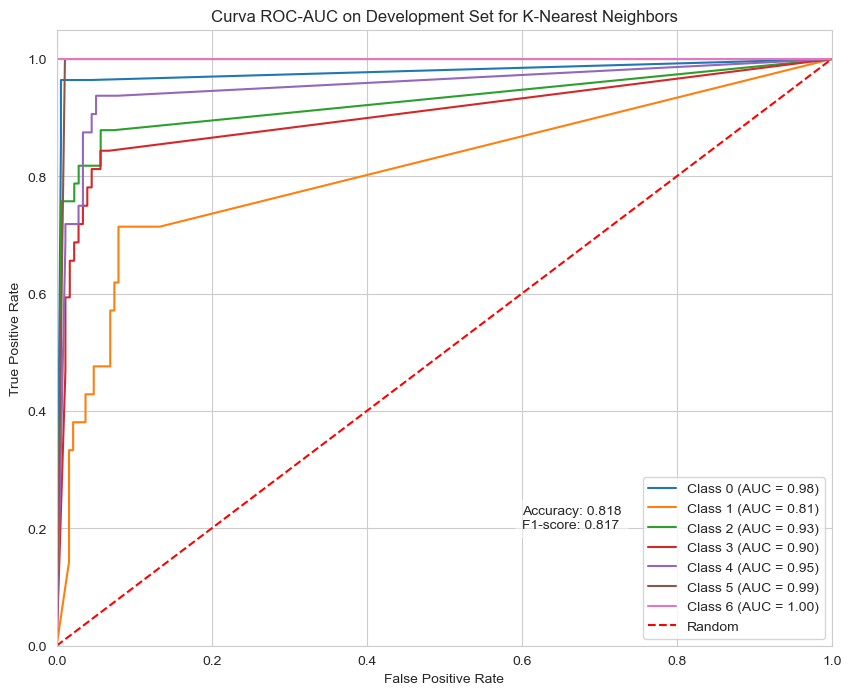

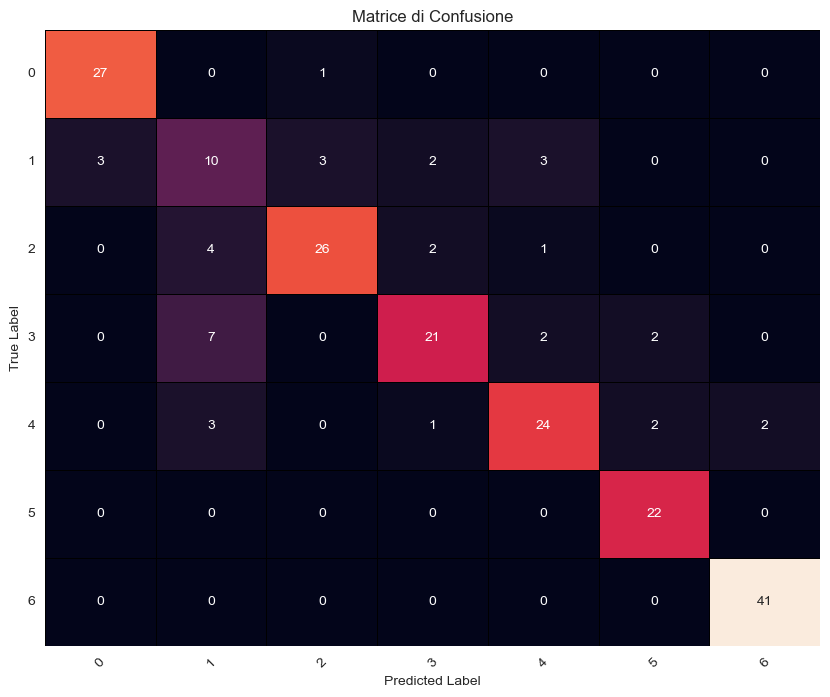

In [32]:
knn_params = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
    'algorithm': ['auto'],
    #, 'ball_tree', 'kd_tree', 'brute'
    'leaf_size': [10, 20, 30, 40]
}
knn_cv = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='accuracy', verbose=1)
start_time_knn = time.time()

knn_cv.fit(X_train_scaled, t_train)

end_time_knn = time.time()
training_time_knn = end_time_knn - start_time_knn

knn_best = knn_cv.best_estimator_

print("Best Parameters Found via GridSearchCV:")
print(knn_cv.best_params_)
print(training_time_knn)

t_train_pred = knn_best.predict(X_train_scaled)
accuracy_train = accuracy_score(t_train, t_train_pred)
f1_train = f1_score(t_train, t_train_pred, average='weighted')
print("Accuracy Training set: ",accuracy_train)
print("F1-score Training set: ",f1_train)

t_dev_pred = knn_best.predict(X_dev_scaled)
accuracy_dev = accuracy_score(t_dev, t_dev_pred)
f1_dev = f1_score(t_dev, t_dev_pred, average='weighted')
plot_roc_auc(knn_best, X_dev_scaled, t_dev, 'K-Nearest Neighbors', accuracy_dev, f1_dev)
plot_confusion_matrix(t_dev, t_dev_pred, labels=list(encoding_mapping['NObeyesdad'].values()))

**Logistic Regression**

Fitting 5 folds for each of 168 candidates, totalling 840 fits
Best Parameters Found via GridSearchCV:
{'C': 1000.0, 'class_weight': 'balanced', 'max_iter': 100, 'penalty': 'l2', 'solver': 'newton-cg'}
86.83908009529114
Accuracy Training set:  0.987813134732566
F1-score Training set:  0.9878130350946843


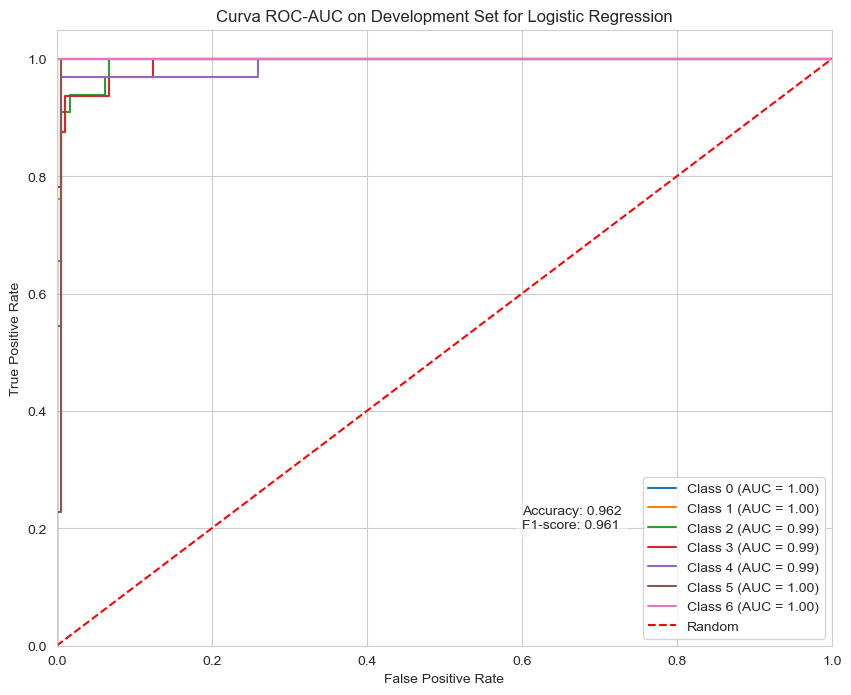

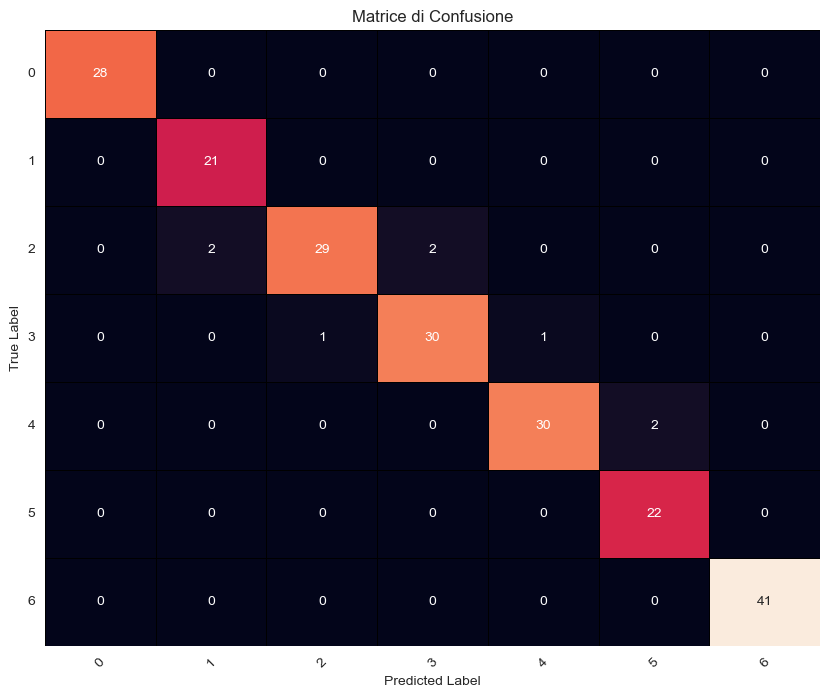

In [33]:
logreg_params = {
    'C': np.logspace(-3, 3, 7),
    'penalty': ['l2'],
    'solver': ['newton-cg', 'lbfgs', 'sag', 'saga'],
    'max_iter': [100, 200, 300],
    'class_weight': [None, 'balanced']
}
logreg_cv = GridSearchCV(LogisticRegression(), logreg_params, cv=5, scoring='accuracy', verbose=1)

start_time_lr = time.time()

logreg_cv.fit(X_train_scaled, t_train)

end_time_lr = time.time()
training_time_lr = end_time_lr - start_time_lr

logreg_best = logreg_cv.best_estimator_

print("Best Parameters Found via GridSearchCV:")
print(logreg_cv.best_params_)
print(training_time_lr)

t_train_pred = logreg_best.predict(X_train_scaled)
accuracy_train = accuracy_score(t_train, t_train_pred)
f1_train = f1_score(t_train, t_train_pred, average='weighted')
print("Accuracy Training set: ",accuracy_train)
print("F1-score Training set: ",f1_train)
    
t_dev_pred = logreg_best.predict(X_dev_scaled)
accuracy_dev = accuracy_score(t_dev, t_dev_pred)
f1_dev = f1_score(t_dev, t_dev_pred, average='weighted')
plot_roc_auc(logreg_best, X_dev_scaled, t_dev, 'Logistic Regression', accuracy_dev, f1_dev)
plot_confusion_matrix(t_dev, t_dev_pred, labels=list(encoding_mapping['NObeyesdad'].values()))

**Support Vector Machine**

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters Found via GridSearchCV:
{'C': 100, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
149.62441325187683
Accuracy Training set:  0.989844278943805
F1-score Training set:  0.9898334324187495


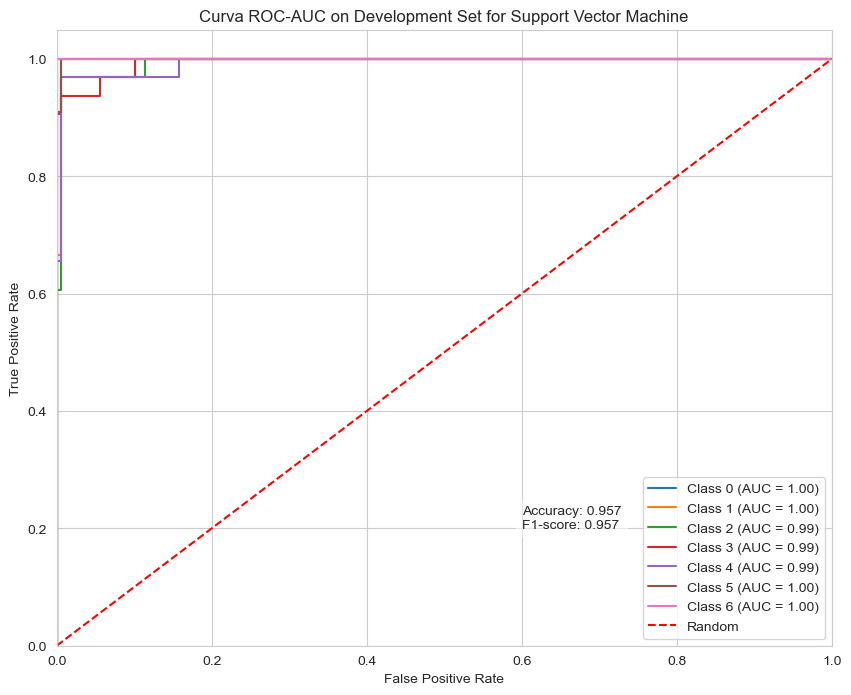

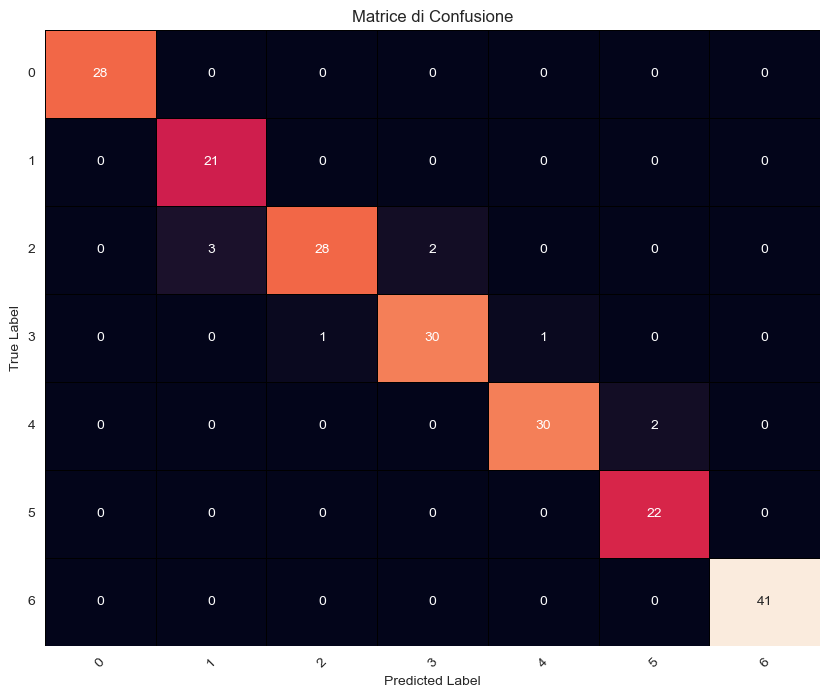

In [34]:
svm_params = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4]
}
svm_cv = GridSearchCV(SVC(probability=True), svm_params, cv=5, scoring='accuracy', verbose=1)

start_time_svm = time.time()

svm_cv.fit(X_train_scaled, t_train)

end_time_svm = time.time()
training_time_svm = end_time_svm - start_time_svm

svm_best = svm_cv.best_estimator_

print("Best Parameters Found via GridSearchCV:")
print(svm_cv.best_params_)
print(training_time_svm)

t_train_pred = svm_best.predict(X_train_scaled)
accuracy_train = accuracy_score(t_train, t_train_pred)
f1_train = f1_score(t_train, t_train_pred, average='weighted')
print("Accuracy Training set: ",accuracy_train)
print("F1-score Training set: ",f1_train)
    
t_dev_pred = svm_best.predict(X_dev_scaled)
accuracy_dev = accuracy_score(t_dev, t_dev_pred)
f1_dev = f1_score(t_dev, t_dev_pred, average='weighted')
plot_roc_auc(svm_best, X_dev_scaled, t_dev, 'Support Vector Machine', accuracy_dev, f1_dev)
plot_confusion_matrix(t_dev, t_dev_pred, labels=list(encoding_mapping['NObeyesdad'].values()))

**Neural Network**

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters Found via GridSearchCV:
{'C': 100, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
290.8579967021942
Accuracy Training set:  1.0
F1-score Training set:  1.0


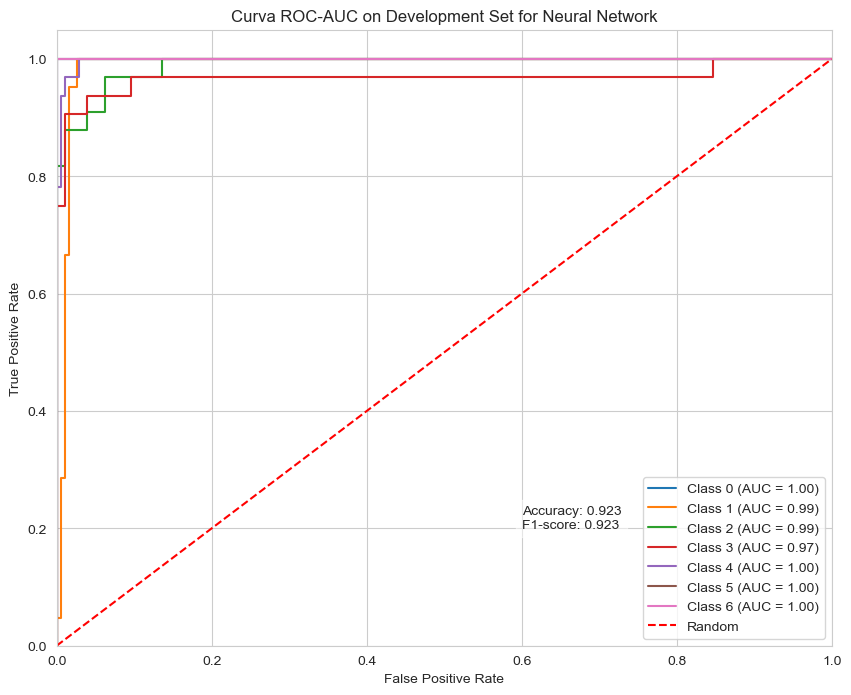

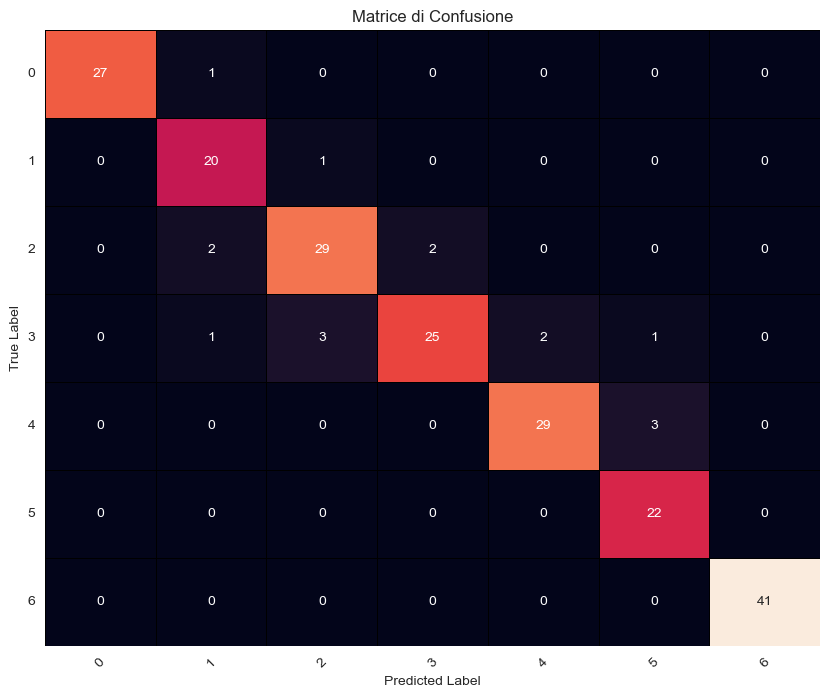

In [35]:
mlp_params = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['logistic', 'tanh', 'relu'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01]
}
mlp_cv = GridSearchCV(MLPClassifier(), mlp_params, cv=5, scoring='accuracy', verbose=1)
start_time_nn = time.time()

mlp_cv.fit(X_train_scaled, t_train)

end_time_nn = time.time()
training_time_nn = end_time_nn - start_time_nn

mlp_best = mlp_cv.best_estimator_

print("Best Parameters Found via GridSearchCV:")
print(svm_cv.best_params_)
print(training_time_nn)
    
t_train_pred = mlp_best.predict(X_train_scaled)
accuracy_train = accuracy_score(t_train, t_train_pred)
f1_train = f1_score(t_train, t_train_pred, average='weighted')
print("Accuracy Training set: ",accuracy_train)
print("F1-score Training set: ",f1_train) 
    
t_dev_pred = mlp_best.predict(X_dev_scaled)
accuracy_dev = accuracy_score(t_dev, t_dev_pred)
f1_dev = f1_score(t_dev, t_dev_pred, average='weighted')
plot_roc_auc(mlp_best, X_dev_scaled, t_dev, 'Neural Network', accuracy_dev, f1_dev)
plot_confusion_matrix(t_dev, t_dev_pred, labels=list(encoding_mapping['NObeyesdad'].values()))

**Selecting the Best Model Based on Accuracy**
Given the dataset's balanced nature and similar F1-score values across models, we will choose the best model based on accuracy.

In [36]:
dev_scores = {
    'Logistic Regression': logreg_best,
    'K-Nearest Neighbors': knn_best,
    'Support Vector Machine': svm_best,
    'Neural Network': mlp_best
}
best_model_name = max(dev_scores, key=lambda x: accuracy_score(t_dev, dev_scores[x].predict(X_dev_scaled)))
best_model = dev_scores[best_model_name]

**Retraining the Best Model on Training + Development Set**
We will retrain the best-performing model on the combined training and development set to utilize all available data for training.

In [37]:
X_train_dev = np.concatenate((X_train_scaled, X_dev_scaled), axis=0)
t_train_dev = np.concatenate((t_train, t_dev), axis=0)
best_model.fit(X_train_dev, t_train_dev)

LogisticRegression(C=1000.0, class_weight='balanced', solver='newton-cg')

**Evaluation of the Best Model on the Test Set (Model Assessment with Fixed Test Set)**

In [38]:
t_test_pred = best_model.predict(X_test_scaled)
accuracy_test = accuracy_score(t_test, t_test_pred)
f1_test = f1_score(t_test, t_test_pred, average='weighted')

**Performance on the Test Set (Final Evaluation)**


Performance on the Test Set Using the Best Model Identified on the Development Set:
Best model: Logistic Regression
Accuracy: 0.9670588235294117
F1-score: 0.9671918435502133


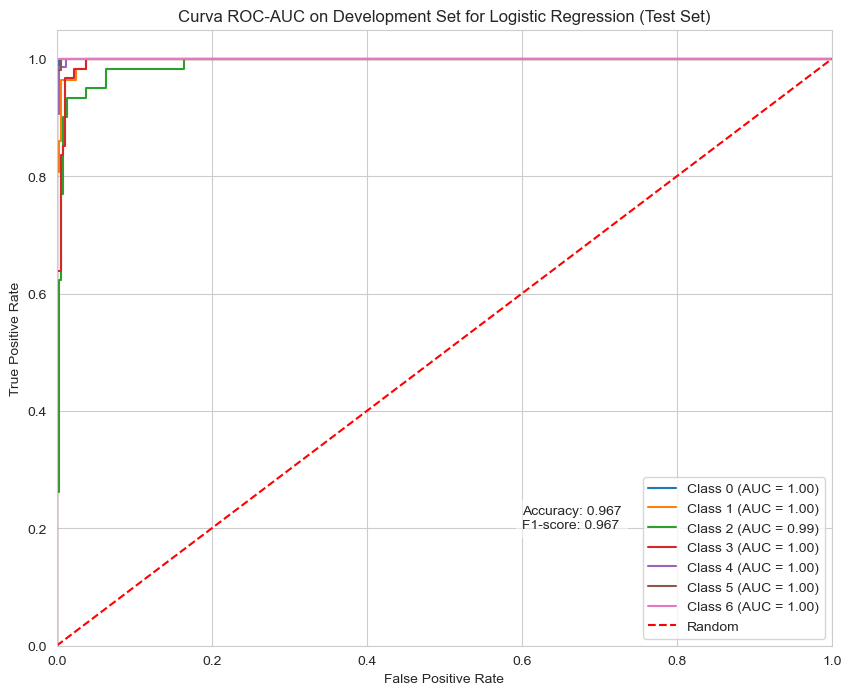

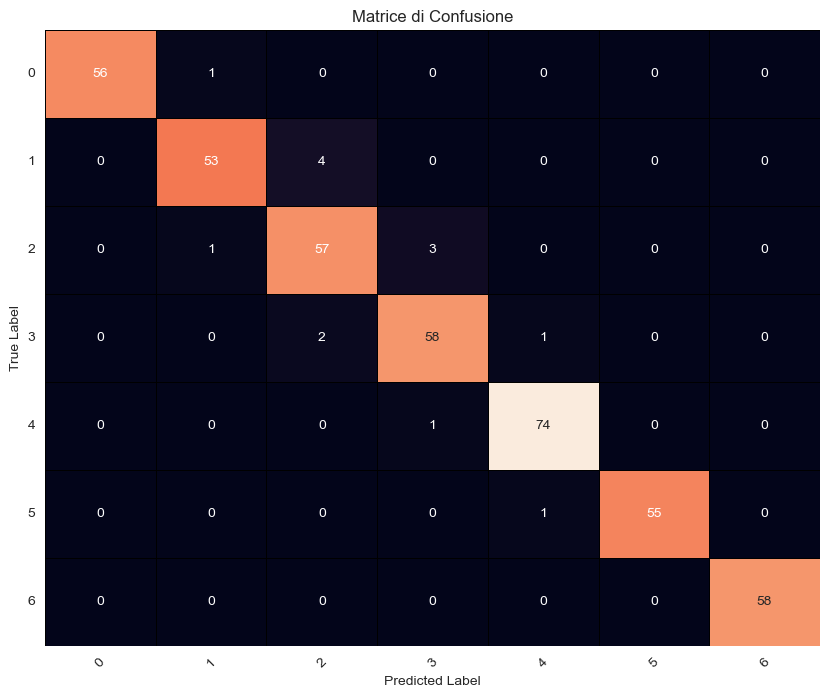

In [39]:
print("\nPerformance on the Test Set Using the Best Model Identified on the Development Set:")
print(f"Best model: {best_model_name}")
print(f"Accuracy: {accuracy_test}")
print(f"F1-score: {f1_test}")
plot_roc_auc(best_model, X_test_scaled, t_test, f"{best_model_name} (Test Set)", accuracy_test, f1_test)
plot_confusion_matrix(t_test, t_test_pred,labels=list(encoding_mapping['NObeyesdad'].values()))